---

# Project: Amazon Product Recommendation System

## Introduction

This project involves developing a recommendation system using Amazon's product reviews dataset, specifically focusing on electronic products. The dataset includes product ratings but excludes additional product information or reviews to maintain an unbiased model-building process.

### Context
The exponential growth of information in terms of volume, velocity, and variety has created significant challenges for consumers, who often face an overwhelming number of choices. Recommender systems provide an effective solution by suggesting relevant products to users while they browse online, enhancing engagement and supporting business goals.

E-commerce platforms like Amazon, Walmart, Target, and Etsy invest heavily in developing sophisticated recommendation models to deliver personalized suggestions. Amazon's recommendation system, known for its accuracy, leverages advanced algorithms to predict customers' preferences and offer tailored product recommendations. A key component of this system is the item-to-item collaborative filtering model, which efficiently handles massive datasets to deliver high-quality, real-time recommendations.

### Objective
The objective is to build a recommendation system to suggest products to Amazon customers based on their previous ratings. Utilizing a labeled dataset of Amazon product reviews, the goal is to extract meaningful insights and develop a model that enhances product recommendations for online consumers. The project will explore various approaches, including:

1. **Knowledge/Rank-Based Recommendation System**:  
   This model recommends products based on predefined rules or ranking criteria, such as popularity or average ratings. It does not consider individual user preferences but instead suggests items that are generally well-rated or popular among all users. This approach is particularly effective for addressing cold start problems by recommending popular items to new users, ensuring relevant suggestions from the start.
2. **User-User Collaborative Filtering**:  
   This model recommends products by identifying users with similar behavior patterns and suggesting items those users have liked or rated highly. The recommendation is based on the idea that users who have similar preferences will like similar items, focusing on user-to-user similarity to make predictions.
3. **Item-Item Collaborative Filtering**:  
   This model works similarly to user-user collaborative filtering but instead focuses on item-to-item similarity. It identifies items that have been rated similarly by the same users and recommends products that are similar to those the user has already interacted with, making it ideal for users with established preferences.
4. **Matrix Factorization-Based Collaborative Filtering**:  
   This model reduces the dimensionality of the user-item interaction matrix using techniques like Singular Value Decomposition (SVD). It captures latent factors that represent both user preferences and item characteristics, predicting missing ratings and making personalized recommendations based solely on user-item interaction data.
5. **Hybrid Recommendation System**:  
   This model combines multiple recommendation techniques, such as collaborative filtering, content-based filtering, and knowledge-based methods, to leverage the strengths of each and mitigate their weaknesses. By integrating different algorithms, the hybrid system aims to improve both the accuracy and relevance of the recommendations.

### Data Dictionary
The Amazon product reviews dataset contains the following attributes:
- **user_id**: A unique identifier for each user.
- **prod_id**: A unique identifier for each product.
- **rating**: The rating given to a product by a user.
- **timestamp**: The time when the rating was given by a given user.

### Performance Metrics
The following key performance metrics will be used to evaluate and guide the comparison and tuning of different recommendation approaches, ensuring the final model provides accurate, diverse, and relevant suggestions to users.

**Predictive Metrics**
- **Root Mean Squared Error (RMSE)**: Measures the difference between predicted and actual ratings, indicating how accurately the model estimates user preferences. Lower RMSE values signify better predictive performance.
- **Precision@K**: The fraction of recommended items that are relevant within the top K predictions. The value of K represents the number of recommendations provided to the user and can be adjusted based on specific needs. Higher precision indicates that the model is effectively recommending items users are likely to engage with.
- **Recall@K**: The fraction of relevant items that are recommended to the user within the top K predictions. Higher recall reflects the model's ability to capture a wider range of items users may find relevant.
- **F1 Score@K**: The harmonic mean of Precision@K and Recall@K. This metric is useful when both precision and recall are important, as it provides a balanced measure that considers both aspects.

**Ranking Metrics**
- **Mean Reciprocal Rank (MRR)**: Measures the ranking quality by averaging the reciprocal rank of the first relevant item in the recommended list. Higher MRR values suggest that relevant items are ranked earlier, enhancing user experience.
- **Mean Average Precision (MAP)**: Evaluates the average precision across all users, indicating how consistently the model ranks relevant items in its recommendations.
- **Hit Rate@K**: The proportion of cases where at least one relevant item is present in the top-K recommendations. A higher hit rate demonstrates the model's reliability in including relevant items.

---

## Importing Necessary Libraries and Data

This section sets up the environment by importing essential libraries for data manipulation, visualization, recommendation system modeling, and evaluation. It includes modules for handling datasets, performing Exploratory Data Analysis (EDA), and building the collaborative filtering models.

In [94]:
# from google.colab import drive
# drive.mount('/content/drive')

In [95]:
# ----------------------------------------------------------------------
# Utility Libraries for Directory and File Handling
# ----------------------------------------------------------------------

# import copy  # For deep copying objects
import pickle  # For serializing and saving Python objects
from pathlib import Path  # For filesystem path handling
import sys  # For managing system paths
import time  # For tracking execution time
import warnings  # For suppressing warnings

# Start timer
start_time = time.time()

# Suppress warnings
warnings.filterwarnings("ignore")

# Add the parent directory to the system path to access custom modules
sys.path.append("../")


In [96]:
# ----------------------------------------------------------------------
# Libraries for Data Manipulation, and Visualization
# ----------------------------------------------------------------------

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

%matplotlib inline

# Jupyter notebook display utilities
from IPython.display import Markdown, display

# ----------------------------------------------------------------------
# Surprise Library for Recommender Systems
# ----------------------------------------------------------------------

# Data loading, parsing and splitting
from surprise.dataset import Dataset
from surprise.reader import Reader # (user ; item ; rating structure)
from surprise.model_selection import train_test_split

# Similarity-based and matrix factorization-based algorithms
from surprise.prediction_algorithms import (
    SVD,
    KNNBaseline,
    KNNBasic,
    KNNWithMeans,
    KNNWithZScore,
    SVDpp,
)


In [97]:
# ----------------------------------------------------------------------
# Import Modules for Recommendation Systems, EDA and Utilities
# ----------------------------------------------------------------------

# Import classes for recommendation systems
from src.cf_recommender import CFRecommendationSystem
from src.hybrid_recommender import HybridRecommendationSystem
from src.rank_recommender import RankRecommendationSystem
from src.content_based_recommendation import content_based_filtering

# Import functions for model evaluation
from src.model_eval_functions import baseline_gridsearch, evaluate_model

# Import functions for exploratory data analysis and utilities
from src.eda_functions import (
    barplot,
    barplot_subplots,
    palette_color,
    plot_interaction_boxplot,
    plot_interaction_histplot,
)

from src.utils import (
    prepare_and_display_metrics,
    read_all_csv_files,
    select_interactions,
)


---

## Loading Data

This section covers loading the dataset from multiple CSV files into a pandas DataFrame, preparing it for subsequent analysis and model development.

In [98]:
# Read the DataFrame | Single File
# raw_data = pd.read_csv("../data/raw/ratings_Electronics.csv", header=None)

# Read the DataFrame | Multiple Files (due to GitHub repo file size limit)
folder_path = "../data/raw"
raw_data = read_all_csv_files(folder_path=folder_path, header=None)

**Reading CSV Files**

Imported: ../data/raw\amazon_product_ratings_part_1.csv
Imported: ../data/raw\amazon_product_ratings_part_2.csv
Imported: ../data/raw\amazon_product_ratings_part_3.csv
Imported: ../data/raw\amazon_product_ratings_part_4.csv
Imported: ../data/raw\amazon_product_ratings_part_5.csv
Imported: ../data/raw\amazon_product_ratings_part_6.csv
Imported: ../data/raw\amazon_product_ratings_part_7.csv
Imported: ../data/raw\amazon_product_ratings_part_8.csv
Imported: ../data/raw\amazon_product_ratings_part_9.csv
Imported: ../data/raw\amazon_product_ratings_part_10.csv
Imported: ../data/raw\amazon_product_ratings_part_11.csv
Imported: ../data/raw\amazon_product_ratings_part_12.csv
Imported: ../data/raw\amazon_product_ratings_part_13.csv

Data import successful. Total files read: 13


In [99]:
# Add column names
raw_data.columns = ["user_id", "prod_id", "rating", "timestamp"]

# Drop colum 'timestamp'
raw_data = raw_data.drop("timestamp", axis=1)

# Create copy of the DataFrame
df = raw_data.copy(deep=True)

# Check number of rows and columns in the dataset
df.shape

(7824494, 3)

## Data Preprocessing

This section addresses the challenges of dataset sparsity and size, with 7.8 million observations, by applying a balanced filtering strategy that iteratively adjusts thresholds for user and product ratings to prevent data loss and ensure a stable dataset size.

In [100]:
# Define initial thresholds
user_threshold = 25
product_threshold = 5

# Define maximum threshold increments for iterative filtering
max_user_threshold = 50
max_product_threshold = 10

# Set convergence flag and initial dataset size
converged = False
prev_size = df.shape[0]

In [101]:
# Initial filtering with low thresholds
user_ratings_count = df["user_id"].value_counts()
df = df[
    df["user_id"].isin(user_ratings_count[user_ratings_count >= user_threshold].index)
]

product_ratings_count = df["prod_id"].value_counts()
df = df[
    df["prod_id"].isin(
        product_ratings_count[product_ratings_count >= product_threshold].index
    )
]

# Set initial values for convergence check
prev_size = df.shape[0]
converged = False

while not converged:
    # Increment thresholds gradually
    if user_threshold < max_user_threshold:
        user_threshold += 5  # Increase user threshold incrementally
    if product_threshold < max_product_threshold:
        product_threshold += 1  # Increase product threshold incrementally

    # Filter users with at least the current user threshold ratings
    user_ratings_count = df["user_id"].value_counts()
    df = df[
        df["user_id"].isin(
            user_ratings_count[user_ratings_count >= user_threshold].index
        )
    ]

    # Filter products with at least the current product threshold ratings
    product_ratings_count = df["prod_id"].value_counts()
    df = df[
        df["prod_id"].isin(
            product_ratings_count[product_ratings_count >= product_threshold].index
        )
    ]

    # Check the current size of the dataset
    current_size = df.shape[0]

    # Check for convergence: if the dataset size decreases significantly, stop iterating
    if abs(prev_size - current_size) > 10000:  # Adjust this value as needed
        converged = True
    else:
        prev_size = current_size

    # If thresholds have reached maximum but no significant change, break to avoid infinite loop
    if (
        user_threshold >= max_user_threshold
        and product_threshold >= max_product_threshold
    ):
        print("Reached maximum thresholds without significant change. Stopping.")
        break

# Final thresholds applied
print(f"user_threshold: {user_threshold}")
print(f"product_threshold: {product_threshold}")

user_threshold: 30
product_threshold: 6


In [102]:
# Reset index of dataset
df.reset_index(drop=True, inplace=True)

## Data Overview

This section provides a high-level summary of the dataset, detailing its dimensions, data types, and an initial look at the first and last few rows, along with checks for duplicate records and counts of unique values to confirm data integrity. The processed and cleaned data is exported as a pickle file for efficient storage and future use.

### High-Level Data Information

In [103]:
# Number of rows and columns
df.shape

(78798, 3)

In [104]:
# First 5 rows
df.head()

,user_id,prod_id,rating
0,A3BMUBUC1N77U8,0972683275,4.0
1,A6J8D9V5S9MBE,0972683275,5.0
2,A3CLWR1UUZT6TG,0972683275,5.0
3,A3TAS1AG6FMBQW,0972683275,5.0
4,ABU4LUKJU2QOY,0972683275,5.0


In [105]:
# Last 5 rows
df.tail()

,user_id,prod_id,rating
78793,A3S3R88HA0HZG3,B00L3YHF6O,5.0
78794,A26VF18X91983P,B00L3YHF6O,5.0
78795,A2XRMQA6PJ5ZJ8,B00L3YHF6O,5.0
78796,A3A4ZAIBQWKOZS,B00L3YHF6O,5.0
78797,AOVTLYTHVDNUX,B00L3YHF6O,5.0


In [106]:
# Summary of DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78798 entries, 0 to 78797
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  78798 non-null  str    
 1   prod_id  78798 non-null  str    
 2   rating   78798 non-null  float64
dtypes: float64(1), str(2)
memory usage: 3.6 MB


### Unique and Duplicate Values

In [107]:
# Number of duplicate rows
dvalues = df.duplicated().sum()

# Convert into DataFrame
duplicate_df = pd.DataFrame({"metric": ["duplicate_rows"], "count": [dvalues]})

# Display DataFrame
duplicate_df

,metric,count
0,duplicate_rows,0


In [108]:
# Number of unique values per feature
nuniq = df.nunique().reset_index()

# Rename column names
nuniq.columns = ["feature", "unique values"]

# Display DataFrame
nuniq

,feature,unique values
0,user_id,1992
1,prod_id,5402
2,rating,5


**Observations**:
- **Dimensions**: The dataset contains **78,798 rows** and **3 columns**.
- **Data Types**: Includes categorical (user and product IDs) and numerical (ratings) features.
- **Data Integrity**: No duplicate records or missing values, ensuring a clean dataset for modeling.
- **Unique Values**: The dataset contains **1,992 unique users** and **5,402 unique products**. The ratings are on a **5-point scale**.
- **Data Sparsity**: Out of **10,760,784 possible user-product interactions**, only **78,798 ratings** are recorded, reflecting typical sparsity in recommendation systems.
- **Additional Insights**: Further details and analyses are presented in subsequent sections.

### Export of Processed Data

In [109]:
# Define the export path and filename for the processed and cleaned dataset
processed_data_filename = "../data/processed/processed_data.pkl"

# Export the dataset
with open(processed_data_filename, "wb") as f:
    pickle.dump(df, f)

# Print status log
print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Processed data exported successfully to '{processed_data_filename}'")

Dimensions: 78798 rows, 3 columns
Processed data exported successfully to '../data/processed/processed_data.pkl'


## Exploratory Data Analysis

This section provides an exploratory data analysis (EDA) of the dataset, examining the distribution of user and product interactions, ratings, and the overall structure, highlighting key trends such as the dominance of high ratings, the presence of outliers, and the skewed distribution of interactions.

### Statistical Analysis of DataFrame

In [110]:
# Select categorical and numerical columns
cat_cols = list(df.select_dtypes(include=["object"]).columns)
num_cols = list(df.select_dtypes(include=[np.number]).columns)

#### Analysis of Numerical Data

In [111]:
# Statistical summary of numerical data
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
rating,78798.0,4.28,0.99,1.0,4.0,5.0,5.0,5.0


**Observations**:
- **Ratings Distribution**: The dataset consists of **78,798 unique ratings** with a **mean of 4.28** and a **median of 5.0**, indicating a strong skew towards higher values. Most ratings are **4.0 or higher**, with many users giving the maximum rating of **5.0**, reflecting a positive feedback trend.

#### Analysis of Categorical Data

In [112]:
# Statistical summary of categorical data
df[cat_cols].describe().T

,count,unique,top,freq
user_id,78798,1992,ADLVFFE4VBT8,283
prod_id,78798,5402,B0088CJT4U,276


**Observations**:
- **User Engagement**: The dataset includes **1,992 unique users**, with varying levels of engagement. The most active user has rated **283 products**, suggesting significant interaction from a small subset of users.
- **Product Popularity**: There are **5,402 unique products** in the dataset. The most frequently rated product has received **276 ratings**, highlighting the uneven distribution of interactions across items. 

### Univariate Analysis of Numerical Columns
For analysis purposes, the 'rating' column, consisting of discrete numbers from 1 to 5, will be treated as a categorical variable. This approach allows us to effectively observe its distribution and patterns.

#### Column | rating

Rating Distribution
------------------------------
 rating  percentage
    1.0        2.72
    2.0        3.95
    3.0       10.46
    4.0       28.63
    5.0       54.24
------------------------------


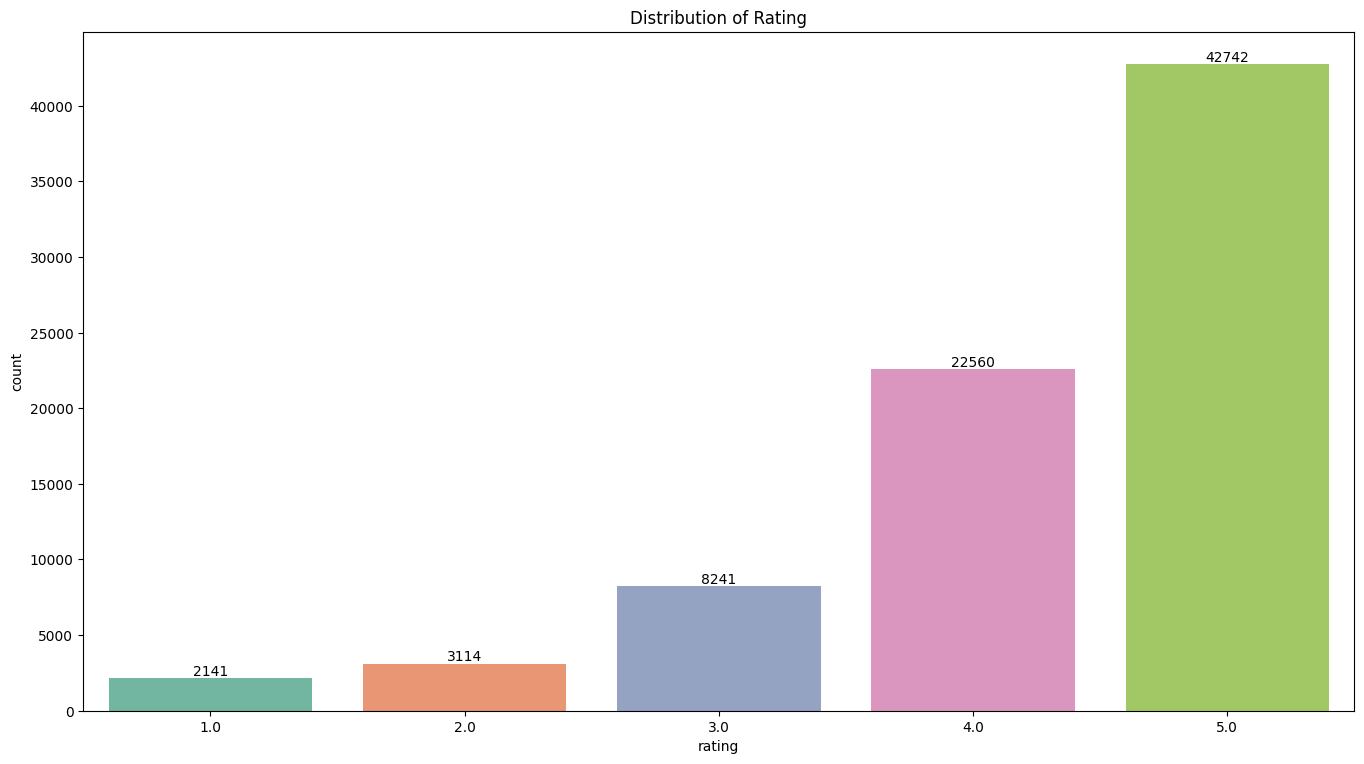

Mean: 4.28, Median: 5.0


In [113]:
# Visualizing the distribution of the feature 'rating' and relative percentage annotations
barplot(df, "rating", perc=False)

**Observations**:
- **Dominance of High Ratings**: A significant **82.87%** of all ratings are either **5.0** (**54.24%**) or **4.0** (**28.63%**), while only **6.67%** are **1.0 or 2.0**. This **left-skewed distribution** indicates a strong user bias towards positive feedback, complicating model generalization.

### Univariate Analysis of Categorical Columns

#### Column | user_id, prod_id

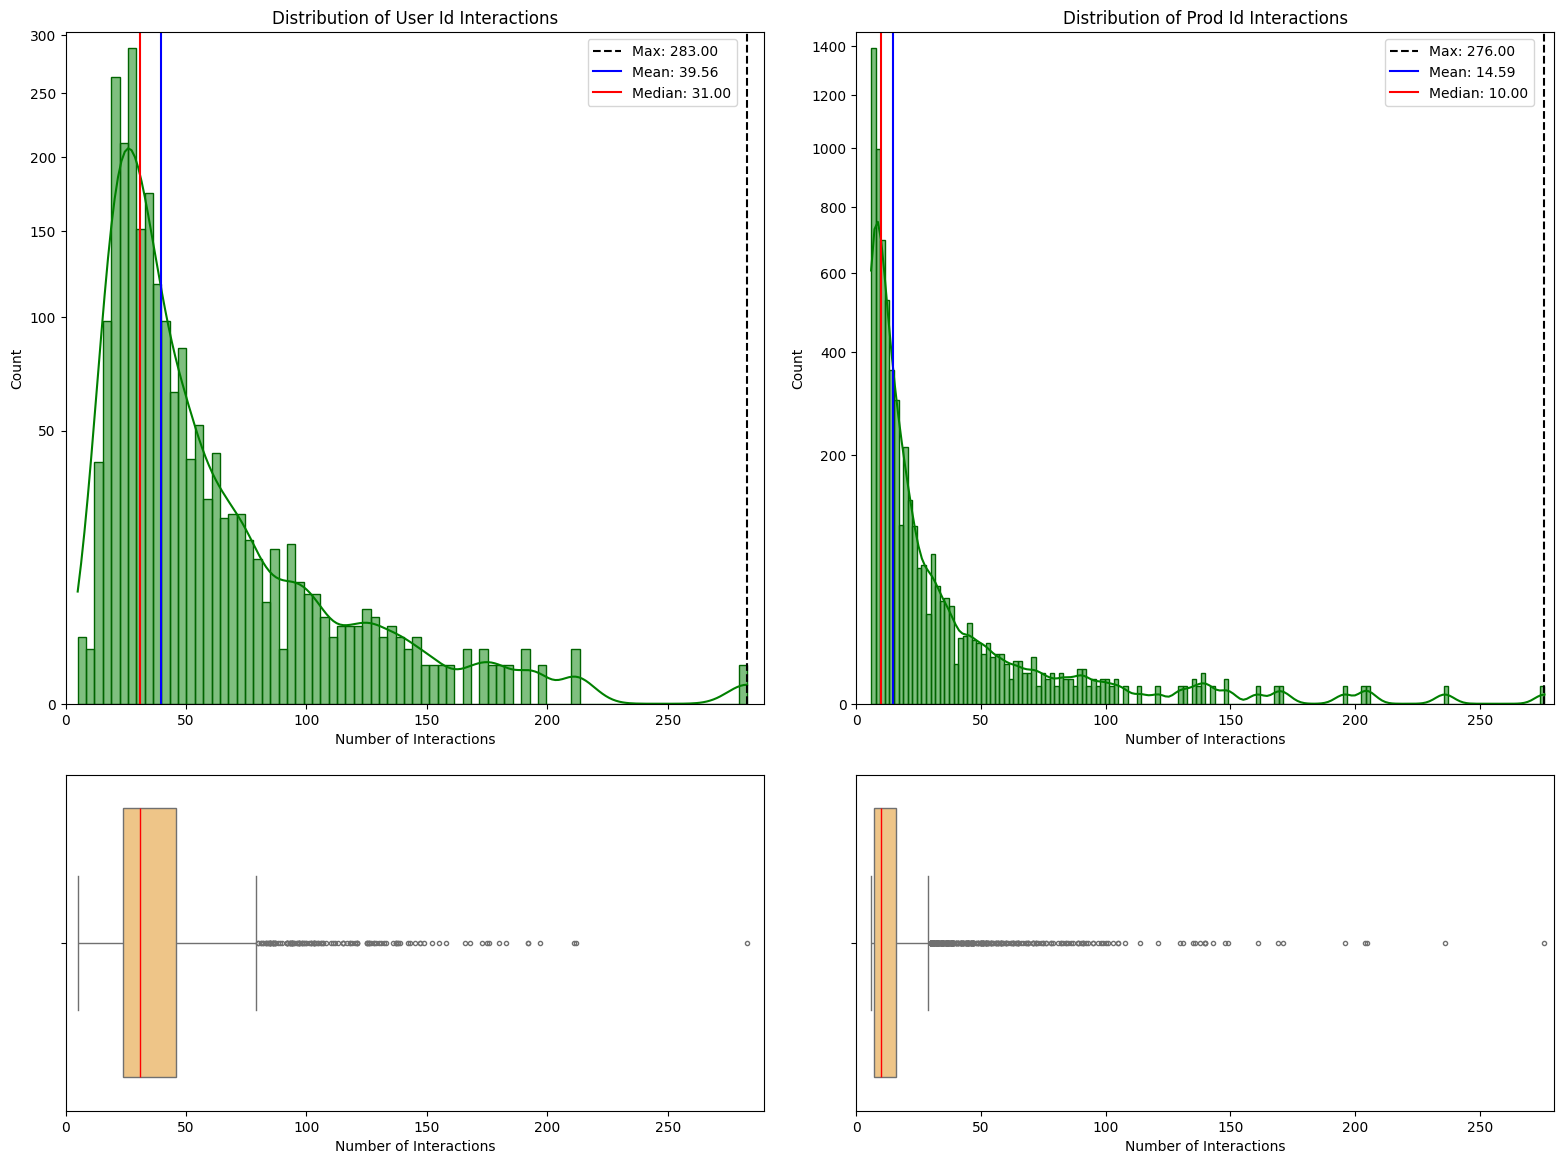

In [114]:
# Note: Histplot y-axis is scaled by square root

# Create a combined figure with GridSpec
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, height_ratios=[2, 1])

# Plotting user-product interactions distribution (histplot)
ax0 = fig.add_subplot(gs[0, 0])
plot_interaction_histplot(df, "user_id", "prod_id", ax0)

# Plotting product-user interactions distribution (histplot)
ax1 = fig.add_subplot(gs[0, 1])
plot_interaction_histplot(df, "prod_id", "user_id", ax1)

# Plotting user-product interactions distribution (boxplot)
ax2 = fig.add_subplot(gs[1, 0])
plot_interaction_boxplot(df, "user_id", "prod_id", ax2)

# Plotting product-user interactions distribution (boxplot)
ax3 = fig.add_subplot(gs[1, 1])
plot_interaction_boxplot(df, "prod_id", "user_id", ax3)

# Synchronize x-axis limits for boxplots
ax2.set_xlim(ax0.get_xlim()[0], ax0.get_xlim()[1])
ax3.set_xlim(ax0.get_xlim()[0], ax1.get_xlim()[1])

plt.tight_layout(pad=2.0)
plt.show()

**Observations**:
- **Interaction Distribution**: Both user-product and product-user interactions are **right-skewed**, with **most users having 10 to 50 interactions** and **most products** interacting with **1 to 10 users**, indicating limited engagement.
- **Outlier Influence**: A small subset of users and products dominate interactions, with the maximum interactions reaching **283** for a user and **276** for a product. These outliers significantly exceed the average, emphasizing the uneven distribution in the dataset.


#### Column | user_id

Top 10 Entries
------------------------------
       user_id  count
  ADLVFFE4VBT8    283
A3OXHLG6DIBRW8    212
A1ODOGXEYECQQ8    211
A36K2N527TXXJN    197
A25C2M3QF9G7OQ    192
 A680RUE1FDO8B    192
A1UQBFCERIP7VJ    183
 AWPODHOB4GFWL    180
A22CW0ZHY3NJH8    176
 AGVWTYW0ULXHT    175
------------------------------


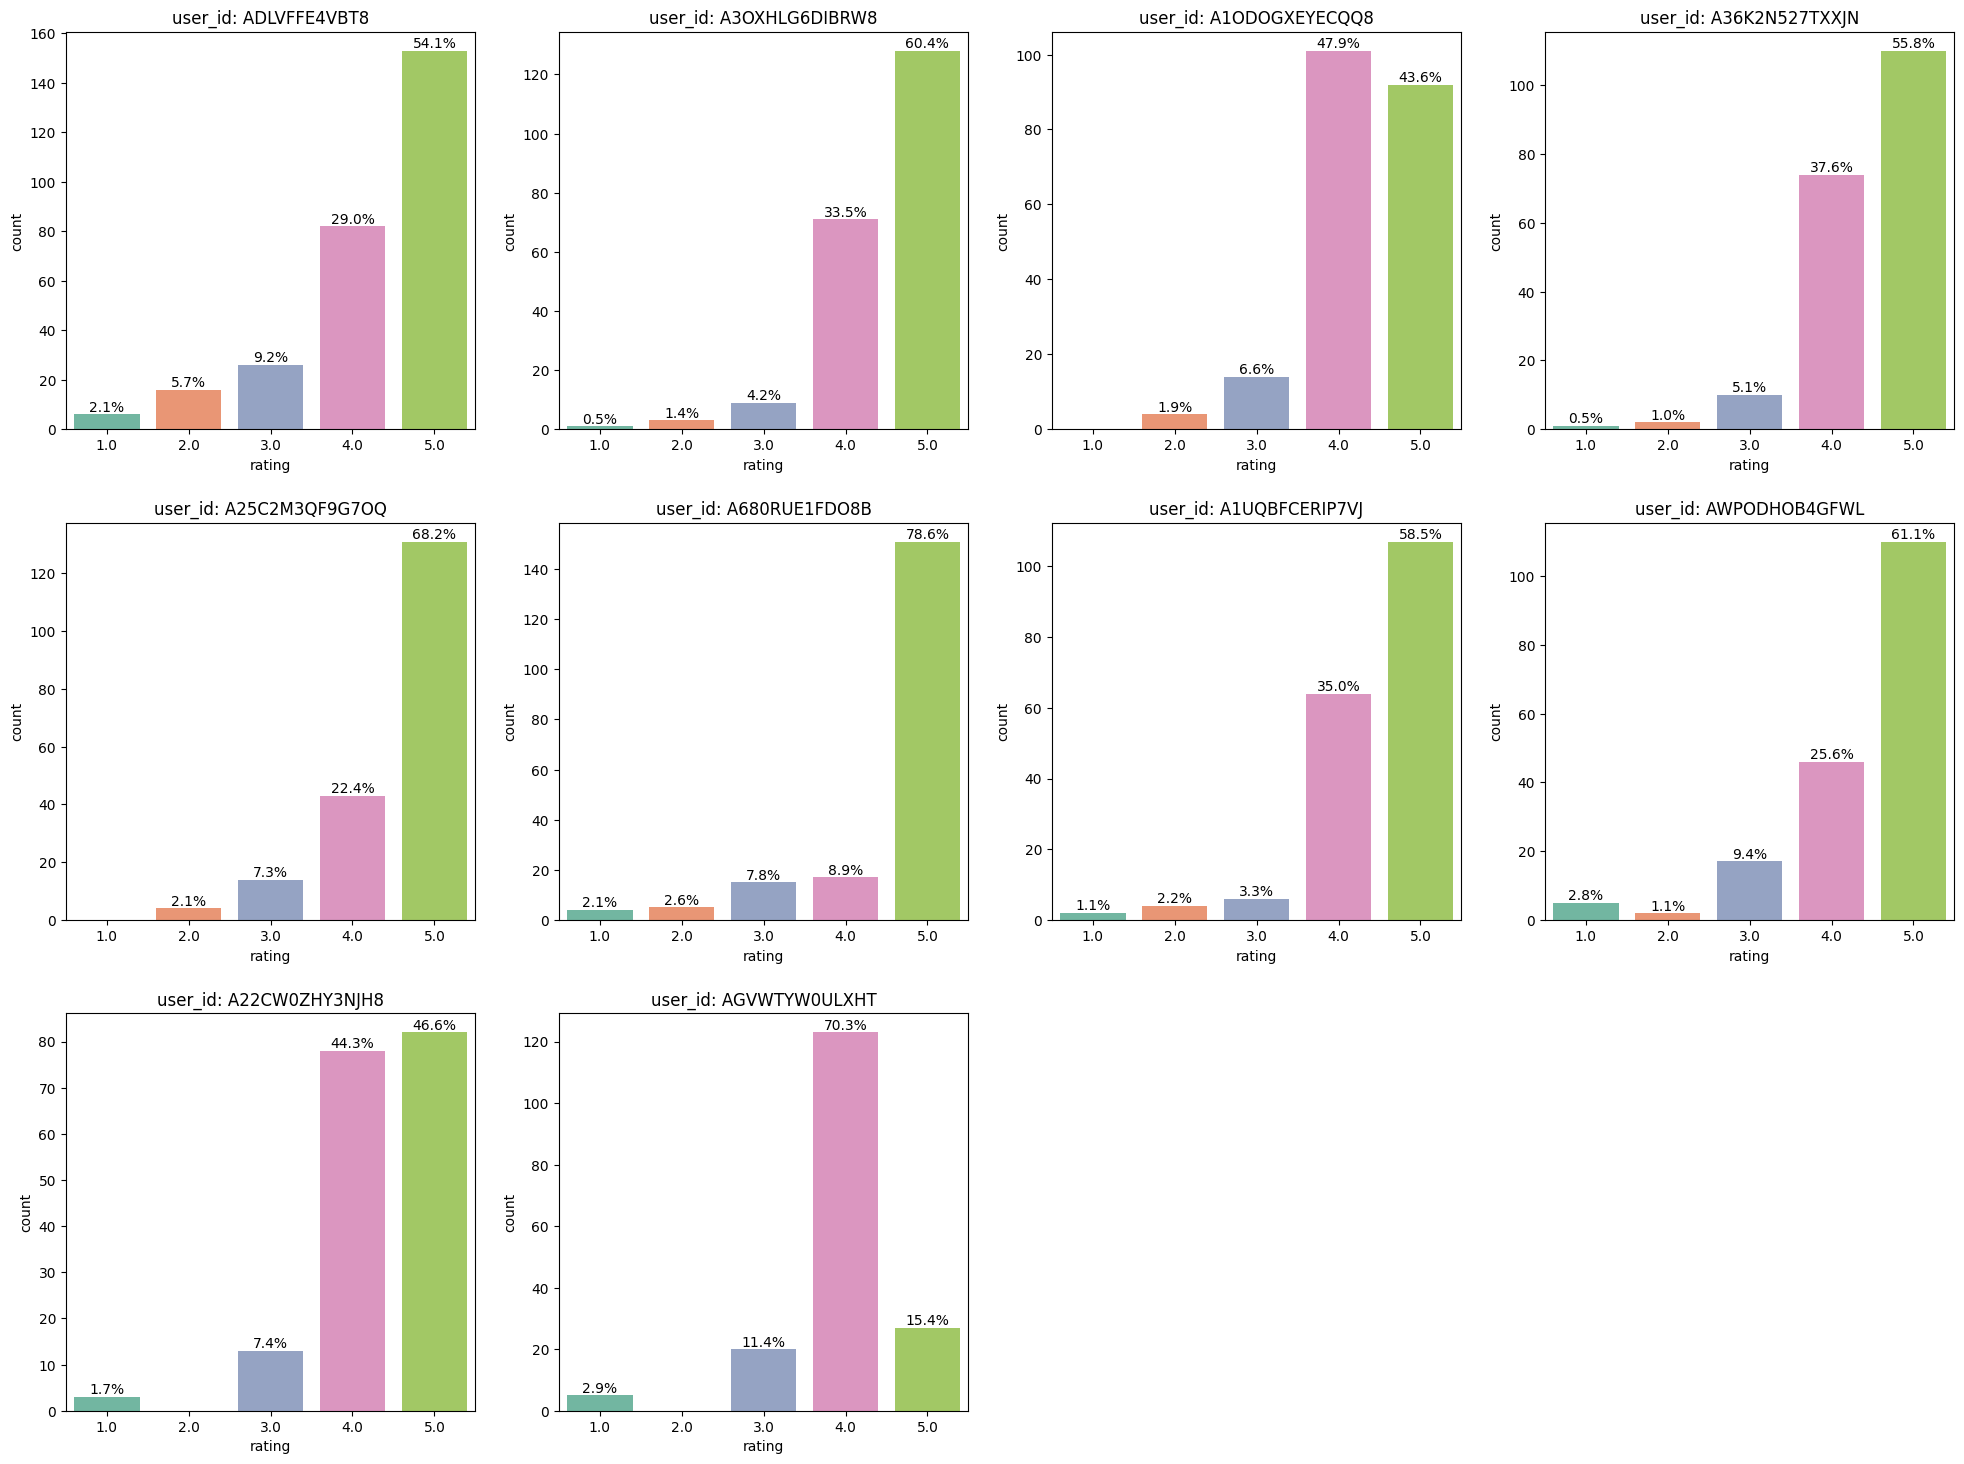

In [115]:
# Visualizing the rating distribution for the top 10 users based on the total number of ratings
features = ["user_id", "rating"]
barplot_subplots(df, features, perc=True)

**Observations**:
- **Top User Engagement**: The most active user, 'ADLVFFE4VBT8', has **283 interactions**, with other top users engaging in **175 to 212 interactions**, indicating significant activity from a small user subset.
- **Positive Rating Bias**: Top users show a strong preference for **5-star ratings**, with percentages ranging from **46.6% to 78.6%**, while **1-star and 2-star ratings** remain rare (averaging **1% to 2%**). This suggests generally positive experiences or a reluctance to give low ratings.
- **Varied Rating Behavior**: While most top users favor **5-star ratings**, some, like 'A1ODOGXEYECQQ8', 'A22CW0ZHY3NJH8', and 'AGVWTYW0ULXHT', also give significant **3-star** and **4-star** ratings, indicating more nuanced satisfaction levels.

#### Column | prod_id

Top 10 Entries
------------------------------
   prod_id  count
B0088CJT4U    276
B003ES5ZUU    236
B00829TIEK    205
B007WTAJTO    204
B000N99BBC    196
B008DWCRQW    171
B00829THK0    169
B00829TIA4    161
B00834SJSK    149
B002R5AM7C    148
------------------------------


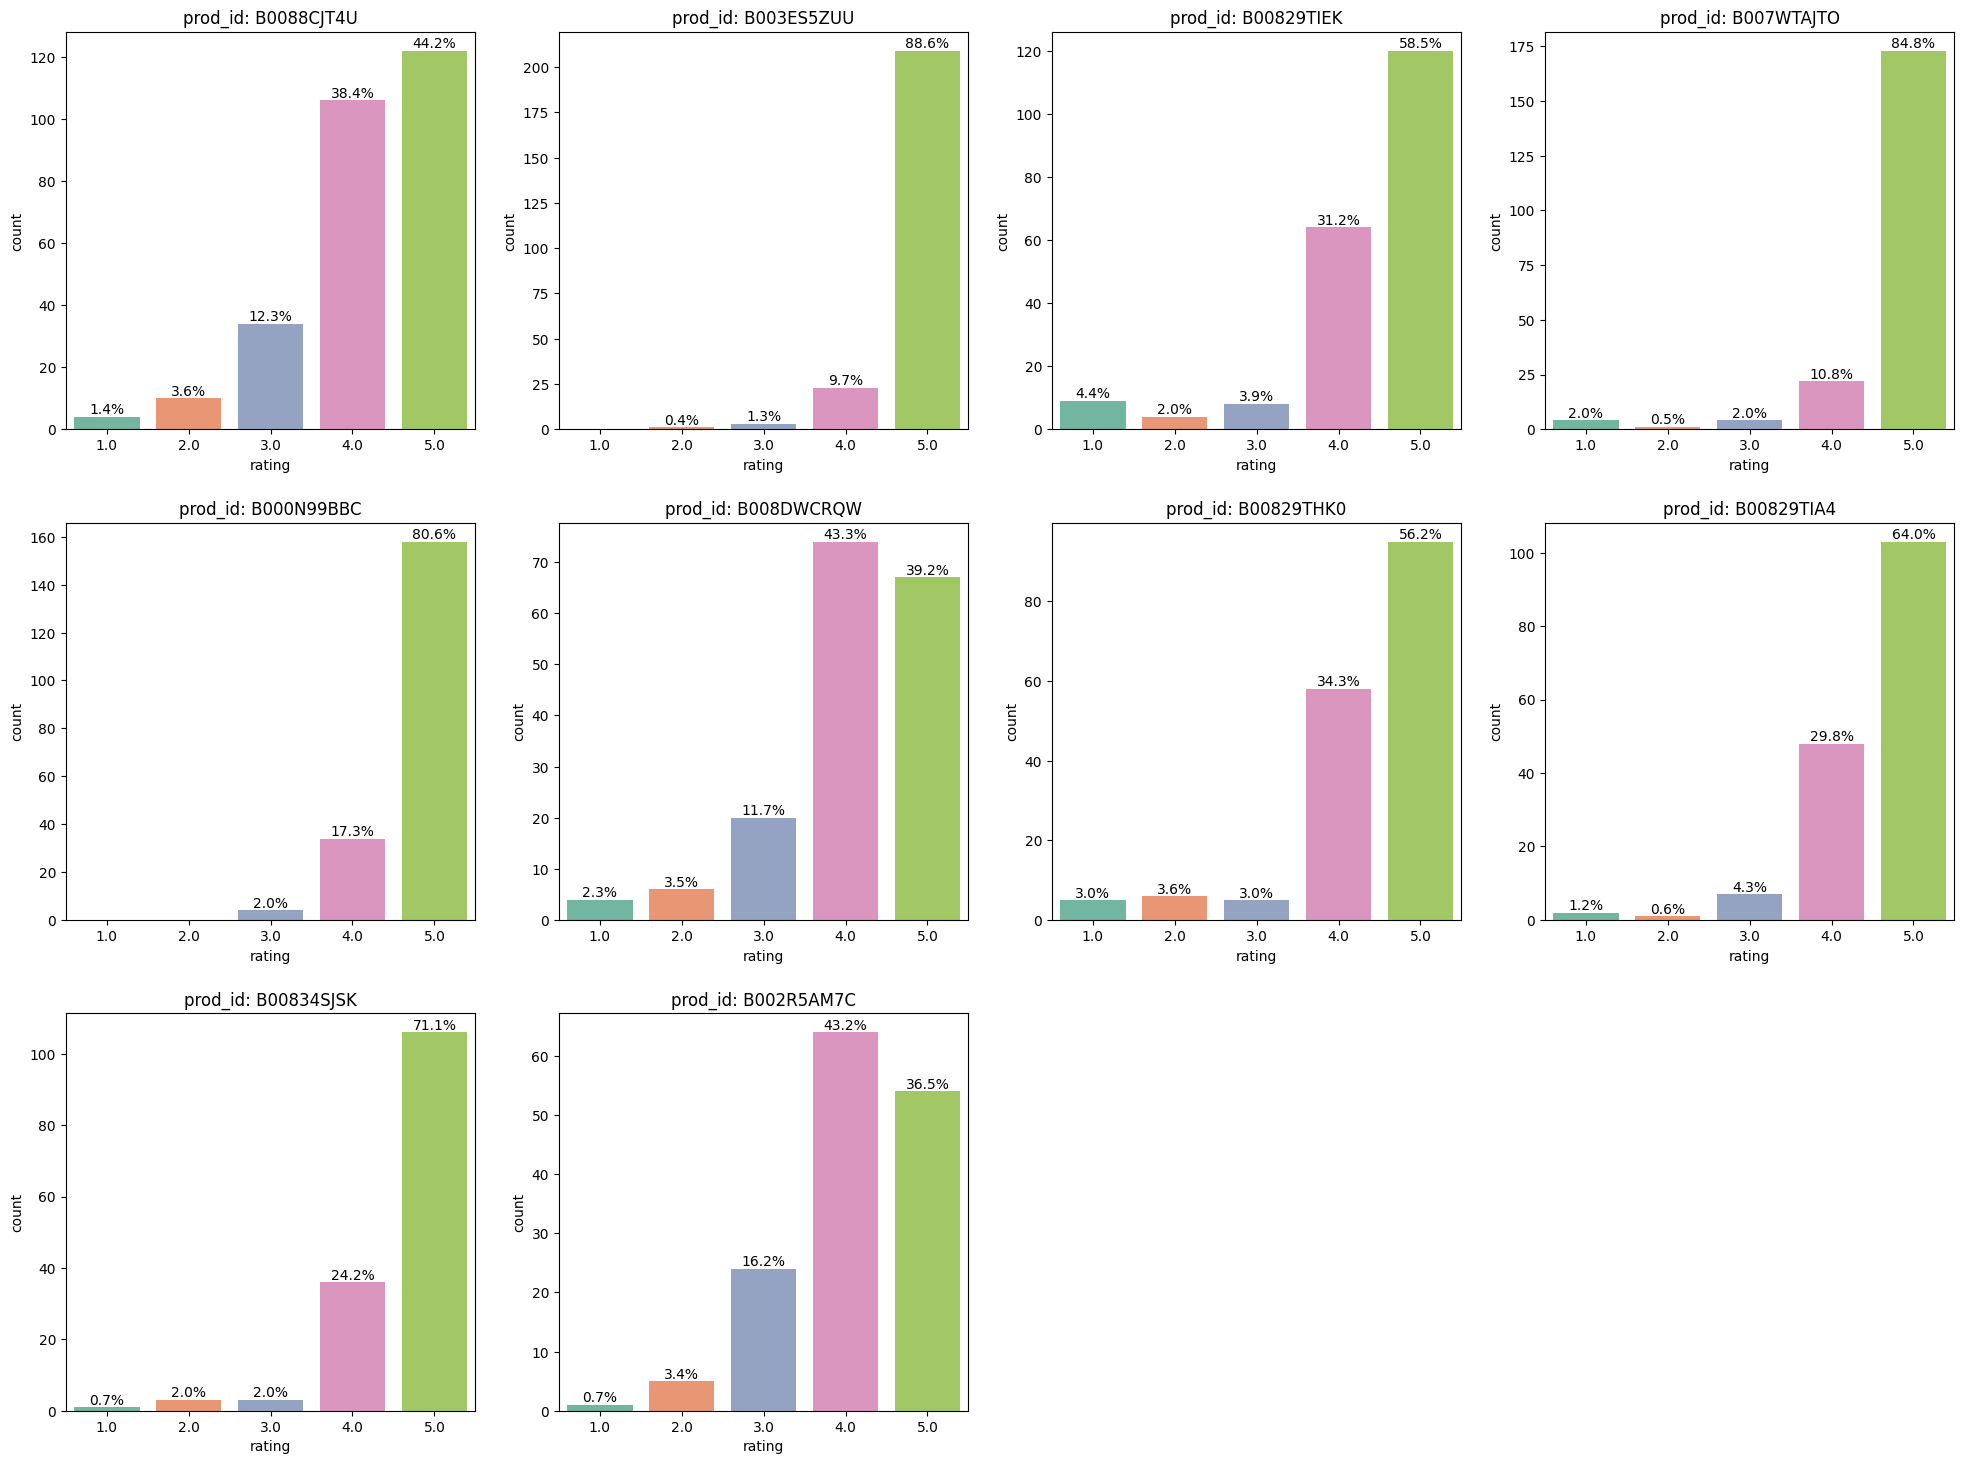

In [116]:
# Visualizing the rating distribution for the top 10 products based on the total number of ratings
features = ["prod_id", "rating"]
barplot_subplots(df, features, perc=True)

**Observations**:
- **Top Products by Interaction**: The most frequently rated product, 'B0088CJT4U', has received **276 ratings**, while other products in the top 10 range from **236 to 148 ratings**, indicating significant engagement with a small subset of products.
- **Positive Rating Bias**: The top products display a strong preference for **5-star ratings**, with percentages spanning **44.2% to 88.6%** while **1-star and 2-star ratings** remain rare (averaging **1% to 2%**). This suggests generally positive experiences or a reluctance to leave poor ratings.
- **Varied Rating Behavior**: While **5-star ratings** dominate, products like 'B0088CJT4U', 'B008DWCRQW', and 'B002R5AM7C' exhibit a more diverse distribution, with significant portions of **3-star** and **4-star ratings**. This points to a more nuanced range of customer satisfaction levels for these items.

## Model Preparation and Setup

This section outlines the model preparation and setup, including loading the dataset into the format required by the `surprise` library, and setting global key variables for model evaluation.

### Data Preprocessing

In [117]:
# Instantiate Reader scale with expected rating scale
reader = Reader(rating_scale=(0, 5))

# Load the rating dataset
data = Dataset.load_from_df(df[["user_id", "prod_id", "rating"]], reader=reader)

# Split the data into train and test datasets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Randomly select user IDs and retrieve their interacted and non-interacted products
user_interactions, user_non_interactions = select_interactions(
    trainset, num_users=2, num_products=4
)

**User Interactions**

{'A1GNYV0RA0EQSS': [('B005TDWX2Q', 5.0),
  ('B00DQZP7X6', 5.0),
  ('B008DWCRQW', 5.0),
  ('B004QGXOOI', 5.0)],
 'A2AY4YUOX2N1BQ': [('B00JWV1LP6', 4.0),
  ('B00316263Y', 5.0),
  ('B001D8S9E2', 5.0),
  ('B00007GQLU', 4.0)]}

**User Non-Interactions**

{'A1GNYV0RA0EQSS': ['B005ELV3HE', 'B00L3YHF6O', 'B0018DQYQ2', 'B005CG2ATQ'],
 'A2AY4YUOX2N1BQ': ['B00C0T7IP4', 'B000UHE8Y2', 'B005YQY5TM', 'B0016O8HP4']}

### Initialization of Key Parameters for Model Evaluation

In [118]:
# Top-K recommendations for evaluation (Precision@K, Recall@K, etc.)
k = 10

# Rating threshold for recommendation relevance
threshold = 4.5  # Increased due to hugh volume of high ratings

# Cross validation iterator
cviter = 5

## Model 1: Rank-Based Recommendation System

This section describes the implementation of the Rank-Based recommendation system, which suggests the most popular items to users based on their overall ratings.
The system employs the **Bayesian Average** to adjust product ratings, accounting for both the global average rating and the number of ratings a product has received. This approach ensures fairer recommendations by minimizing bias toward items with fewer ratings and effectively addresses cold start issues by recommending popular items to new users, even in the absence of prior interactions.

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

$$\text{Bayesian Avg.} = \frac{\bar{R} \times k + \sum R}{k + N}$$

where:
- $\bar{R}$ is the global average rating.
- $k$ is the regularization parameter (often set to the average number of ratings across items).
- $\sum R$ is the sum of ratings for the specific item.
- $N$ is the number of ratings for the specific item.

### Baseline Model

In [119]:
# Initialize the rank-based recommendation system using Bayesian average scoring
model_rank = RankRecommendationSystem(method="bayesian")

# Compute scores for products using the chosen rank-based method
model_rank.compute_scores(data=df, gb_feature="prod_id", filter_feature="rating")

In [120]:
# Evaluate the rank-based model
model_rank_metric = model_rank.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.900,0.899
Precision@K,0.786,0.565
Recall@K,0.269,0.260
F1 Score@K,0.401,0.356


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.905,0.842
MAP,0.840,0.791
Hit Rate@K,0.995,0.943


In [121]:
# Generate top-N product recommendations ranked by the Bayesian average score
model_rank.recommend(top_n=5, threshold=0)

**Recommendations for All Users**

,prod_id,estimated_ratings
0,B0052SCU8U,4.86
1,B003ES5ZUU,4.83
2,B001TH7GUU,4.83
3,B00BQ4F9ZA,4.77
4,B001TH7GSW,4.77


In [122]:
# Generate top-N product recommendations, with at least 100 user-item interactions, ranked by the Bayesian average score
model_rank.recommend(top_n=5, threshold=100)

**Recommendations for All Users**

,prod_id,estimated_ratings
0,B003ES5ZUU,4.83
1,B000N99BBC,4.75
2,B000QUUFRW,4.74
3,B007WTAJTO,4.73
4,B002WE6D44,4.71


**Observations**:

- **RMSE**: The model shows consistency across both train **RMSE** (0.900) and test **RMSE** (0.899), reflecting moderate accuracy. The minimal difference suggests the model is not overfitting and maintains stable performance on unseen data.
- **Prediction Metrics**: Moderate **Precision@K** (0.565) and low **Recall@K** (0.260) on the test set, indicating a reasonable level of relevance in the top-10 recommendations but difficulties in retrieving all relevant items within the sparse dataset.
- **Ranking Metrics**: High **MRR** (0.842) and **MAP** (0.791) on the test set indicate strong ranking performance, primarily due to the model's ability to identify and rank popular, frequently interacted products. A **Hit Rate@K** of 0.943 shows that the model consistently includes at least one relevant item in its top-K recommendations. However, this performance may be inflated by data sparsity and the dominance of popular, top-rated products, simplifying the ranking process for the model.
- **Cold Start and Recommendations**: The model effectively addresses the cold start problem by recommending highly-rated, popular items to new users with no prior interaction data using the **Bayesian Average**, which balances global ratings with the number of interactions each product has received.

## Model 2: User-User Collaborative Filtering Recommendation System

This section focuses on developing a User-User Collaborative Filtering recommendation system using **k-Nearest Neighbors (k-NN)** algorithms.
It starts with a grid search to identify the optimal algorithm for the baseline model, followed by tuning key parameters, including similarity measures and hyperparameters such as the number of neighbors and the minimum number of neighbors.

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline Model

In [123]:
# Common base parameter grid for most k-NN algorithms
base_knn_param_grid = {
    "k": [10, 20, 30],  # Number of nearest neighbor
    "min_k": [1, 3, 5],  # Minimum number of nearest neighbor
    "sim_options": {
        "name": ["cosine", "msd", "pearson"],
        "user_based": [True],
    },
}

# Specific parameter grid for KNNBaseline algorithm
knn_baseline_param_grid = {
    **base_knn_param_grid,  # Use the base grid and extend it
    "sim_options": {
        "name": ["cosine", "msd", "pearson", "pearson_baseline"],
        "user_based": [True],
    },
}

# Combine all parameter grids into one dictionary
knn_param_grids = {
    "KNNBasic": base_knn_param_grid,
    "KNNWithMeans": base_knn_param_grid,
    "KNNWithZScore": base_knn_param_grid,
    "KNNBaseline": knn_baseline_param_grid,
}


# Combine the parameter grids into a dictionary
knn_algorithms = {
    "KNNBasic": KNNBasic,
    "KNNWithMeans": KNNWithMeans,
    "KNNWithZScore": KNNWithZScore,
    "KNNBaseline": KNNBaseline,
}

# Run grid search for all k-NN algorithms
knn_baseline_name, knn_baseline_params = baseline_gridsearch(
    data, knn_algorithms, knn_param_grids, cv=cviter
)

<br>**Baseline Gridsearch Results**


Algorithm: KNNBasic
RMSE: 0.955
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': True}}

Algorithm: KNNWithMeans
RMSE: 0.916
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': True}}

Algorithm: KNNWithZScore
RMSE: 0.915
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': True}}

Algorithm: KNNBaseline
RMSE: 0.893
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': True}}


<br>**-------------------------------- BASELINE MODEL SELECTION: KNNBaseline ---------------------------------**

In [124]:
# Select the k-Nearest Neighbors (kNN) algorithm and corresponding parameter grid
model = knn_algorithms[knn_baseline_name]
params_grid = knn_baseline_params

# Initialize the baseline recommendation system
model_uu = CFRecommendationSystem(data=data, algo_class=model, params_grid=params_grid)

In [125]:
# Train the model
model_uu.fit_knn(trainset=trainset, use_tuned_params=False)

Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': True}, 'verbose': False}


In [126]:
# Evaluate the model's performance
model_uu_metric = model_uu.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.758,0.892
Precision@K,0.809,0.503
Recall@K,0.344,0.341
F1 Score@K,0.483,0.406


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.951,0.808
MAP,0.897,0.755
Hit Rate@K,0.995,0.943


In [127]:
# Perform cross-validation
model_uu.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8875  0.8828  0.8932  0.9076  0.8870  0.8916  0.0086  
MAE (testset)     0.6609  0.6610  0.6648  0.6766  0.6630  0.6653  0.0058  
Fit time          0.92    1.09    1.13    1.01    0.89    1.01    0.09    
Test time         0.49    0.42    0.42    0.46    0.43    0.45    0.03    


In [128]:
# Predict ratings for interacted products
model_uu.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.59   {'actual_k': 13, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.54   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.85   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 2, 'was_impossible': False}


In [129]:
# Predict ratings for non-interacted products
model_uu.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 0, 'was_impossible': False}


### Tuned Model

In [130]:
# Extract similarity names based on algorithm
sim_names = (
    ["cosine", "msd", "pearson", "pearson_baseline"]
    if "Baseline" in knn_baseline_name
    else ["cosine", "msd", "pearson"]
)

# Prepare the parameter grid for hyperparameter tuning
param_grid = {
    "k": [32, 33, 34],
    "min_k": [12, 13, 14],
    "sim_options": {
        "name": sim_names,
        "user_based": [True],
    },
}

# Tune the hyperparameters using the specified grid
model_uu.tune_hyperparameters(param_grid=param_grid, measures=["rmse"], cv=cviter)

<br>**Hyperparameter Tuning Grid**

{'k': [32, 33, 34],
 'min_k': [12, 13, 14],
 'sim_options': {'name': ['cosine', 'msd', 'pearson', 'pearson_baseline'],
  'user_based': [True]}}

<br>**Hyperparameter Tuning Results**

RMSE: 0.889
Parameters: {'k': 34, 'min_k': 14, 'sim_options': {'name': 'pearson', 'user_based': True}}


In [131]:
# Train the model
model_uu.fit_knn(trainset=trainset, use_tuned_params=True)

Parameters: {'k': 34, 'min_k': 14, 'sim_options': {'name': 'pearson', 'user_based': True}, 'verbose': False}


In [132]:
# Evaluate the model's performance
model_uu_opt_metric = model_uu.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.820,0.888
Precision@K,0.724,0.496
Recall@K,0.292,0.336
F1 Score@K,0.416,0.401


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.927,0.813
MAP,0.864,0.757
Hit Rate@K,0.995,0.943


In [133]:
# Perform cross-validation
model_uu.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8942  0.8923  0.8782  0.8985  0.8829  0.8892  0.0075  
MAE (testset)     0.6676  0.6656  0.6573  0.6679  0.6625  0.6642  0.0039  
Fit time          0.99    1.06    1.08    1.02    0.87    1.00    0.08    
Test time         0.44    0.45    0.37    0.34    0.34    0.39    0.05    


In [134]:
# Predict ratings for interacted products
model_uu.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.05   {'actual_k': 13, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.54   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.85   {'actual_k': 2, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 2, 'was_impossible': False}


In [135]:
# Predict ratings for non-interacted products
model_uu.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 0, 'was_impossible': False}


In [136]:
# Get the top 5 recommendations for user IDs
model_uu.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.77,"{'actual_k': 1, 'was_impossible': False}"
1,B00BQ4F9ZA,4.76,"{'actual_k': 0, 'was_impossible': False}"
2,B0000BZL1P,4.75,"{'actual_k': 0, 'was_impossible': False}"
3,B001TH7GUU,4.74,"{'actual_k': 0, 'was_impossible': False}"
4,B000N99BBC,4.73,"{'actual_k': 4, 'was_impossible': False}"


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.98,"{'actual_k': 1, 'was_impossible': False}"
1,B00BQ4F9ZA,4.96,"{'actual_k': 1, 'was_impossible': False}"
2,B0000BZL1P,4.96,"{'actual_k': 1, 'was_impossible': False}"
3,B001TH7GUU,4.95,"{'actual_k': 3, 'was_impossible': False}"
4,B000N99BBC,4.93,"{'actual_k': 1, 'was_impossible': False}"


**Observations**:

- **RMSE**: Tuning increases the train **RMSE** (0.758 to 0.820), indicating reduced overfitting. However, the minimal change in test **RMSE** (0.892 to 0.888) suggests limited improvement in generalization.
- **Prediction Metrics**: **Precision@K** decreases on the training side after tuning (from 0.809 to 0.724) due to the mitigation of overfitting. On the test side, **Precision@K** remains relatively stable with a slight decrease (from 0.503 to 0.496). **Recall@K** shows a similar trend (train: 0.344 to 0.292; test: 0.341 to 0.336), indicating a more balanced performance with minor changes in recommendation relevance and item retrieval.
- **Ranking Metrics**: High **MRR**, **MAP**, and **Hit Rate@K** are maintained in both baseline and tuned versions, indicating strong ranking performance primarily driven by popular items. The minimal change post-tuning suggests potential inflation of these metrics due to data sparsity and the dominance of well-rated products, making further enhancement through tuning challenging.
- **Overfitting and Sparse Data**: While tuning reduces overfitting, sparse interactions and the reliance on popular items continue to limit the model's generalization.

## Model 3: Item-Item Collaborative Filtering Recommendation System

This section focuses on developing a Item-Item Collaborative Filtering recommendation system using **k-Nearest Neighbors (k-NN)** algorithms.
It starts with a grid search to identify the optimal algorithm for the baseline model, followed by tuning key parameters, including similarity measures and hyperparameters such as the number of neighbors and the minimum number of neighbors.

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline Model

In [137]:
# Common base parameter grid for most k-NN algorithms
base_knn_param_grid = {
    "k": [10, 20, 30],  # Number of nearest neighbor
    "min_k": [1, 3, 5],  # Minimum number of nearest neighbor
    "sim_options": {
        "name": ["cosine", "msd", "pearson"],
        "user_based": [False],
    },
}

# Specific parameter grid for KNNBaseline algorithm
knn_baseline_param_grid = {
    **base_knn_param_grid,  # Use the base grid and extend it
    "sim_options": {
        "name": ["cosine", "msd", "pearson", "pearson_baseline"],
        "user_based": [False],
    },
}

# Combine all parameter grids into one dictionary
knn_param_grids = {
    "KNNBasic": base_knn_param_grid,
    "KNNWithMeans": base_knn_param_grid,
    "KNNWithZScore": base_knn_param_grid,
    "KNNBaseline": knn_baseline_param_grid,
}


# Combine the parameter grids into a dictionary
knn_algorithms = {
    "KNNBasic": KNNBasic,
    "KNNWithMeans": KNNWithMeans,
    "KNNWithZScore": KNNWithZScore,
    "KNNBaseline": KNNBaseline,
}

# Run grid search for all k-NN algorithms
knn_baseline_name, knn_baseline_params = baseline_gridsearch(
    data, knn_algorithms, knn_param_grids, cv=cviter
)

<br>**Baseline Gridsearch Results**


Algorithm: KNNBasic
RMSE: 0.966
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'msd', 'user_based': False}}

Algorithm: KNNWithMeans
RMSE: 0.93
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': False}}

Algorithm: KNNWithZScore
RMSE: 0.934
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': False}}

Algorithm: KNNBaseline
RMSE: 0.891
Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': False}}


<br>**-------------------------------- BASELINE MODEL SELECTION: KNNBaseline ---------------------------------**

In [138]:
# Select the k-Nearest Neighbors (kNN) algorithm and corresponding parameter grid
model = knn_algorithms[knn_baseline_name]
params_grid = knn_baseline_params

# Initialize the baseline recommendation system
model_ii = CFRecommendationSystem(data=data, algo_class=model, params_grid=params_grid)

In [139]:
# Train the model
model_ii.fit_knn(trainset=trainset, use_tuned_params=False)

Parameters: {'k': 30, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': False}, 'verbose': False}


In [140]:
# Evaluate the model's performance
model_ii_metric = model_ii.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.751,0.891
Precision@K,0.775,0.497
Recall@K,0.318,0.338
F1 Score@K,0.451,0.402


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.959,0.809
MAP,0.908,0.755
Hit Rate@K,0.997,0.943


In [141]:
# Perform cross-validation
model_ii.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8937  0.8847  0.8856  0.8936  0.8970  0.8909  0.0049  
MAE (testset)     0.6686  0.6621  0.6609  0.6661  0.6667  0.6649  0.0029  
Fit time          2.02    2.03    2.01    1.97    1.92    1.99    0.04    
Test time         0.51    0.51    0.50    0.50    0.49    0.50    0.01    


In [142]:
# Predict ratings for interacted products
model_ii.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 2, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 3, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.53   {'actual_k': 7, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.17   {'actual_k': 8, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.85   {'actual_k': 3, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 1, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 3, 'was_impossible': False}


In [143]:
# Predict ratings for non-interacted products
model_ii.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 1, 'was_impossible': False}


### Tuned Model

In [144]:
# Extract similarity names based on algorithm
sim_names = (
    ["cosine", "msd", "pearson", "pearson_baseline"]
    if "Baseline" in knn_baseline_name
    else ["cosine", "msd", "pearson"]
)

# Prepare the parameter grid for hyperparameter tuning
param_grid = {
    "k": [34, 35, 36],
    "min_k": [13, 14, 15],
    "sim_options": {
        "name": sim_names,
        "user_based": [False],
    },
}

# Tune the hyperparameters using the specified grid
model_ii.tune_hyperparameters(param_grid=param_grid, measures=["rmse"], cv=cviter)

<br>**Hyperparameter Tuning Grid**

{'k': [34, 35, 36],
 'min_k': [13, 14, 15],
 'sim_options': {'name': ['cosine', 'msd', 'pearson', 'pearson_baseline'],
  'user_based': [False]}}

<br>**Hyperparameter Tuning Results**

RMSE: 0.889
Parameters: {'k': 36, 'min_k': 15, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}}


In [145]:
# Train the model
model_ii.fit_knn(trainset=trainset, use_tuned_params=True)

Parameters: {'k': 36, 'min_k': 15, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}, 'verbose': False}


In [146]:
# Evaluate the model's performance
model_ii_opt_metric = model_ii.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.804,0.888
Precision@K,0.721,0.496
Recall@K,0.296,0.337
F1 Score@K,0.420,0.401


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.927,0.813
MAP,0.870,0.758
Hit Rate@K,0.995,0.943


In [147]:
# Perform cross-validation
model_ii.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8997  0.8887  0.8826  0.8875  0.8851  0.8887  0.0059  
MAE (testset)     0.6692  0.6641  0.6596  0.6601  0.6656  0.6637  0.0035  
Fit time          1.50    1.55    1.52    1.48    1.45    1.50    0.03    
Test time         0.56    0.56    0.56    0.53    0.51    0.54    0.02    


In [148]:
# Predict ratings for interacted products
model_ii.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.37   {'actual_k': 5, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.25   {'actual_k': 6, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.05   {'actual_k': 11, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.41   {'actual_k': 4, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.54   {'actual_k': 9, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 5.00   {'actual_k': 18, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'actual_k': 3, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'actual_k': 6, 'was_impossible': False}


In [149]:
# Predict ratings for non-interacted products
model_ii.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.94   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.56   {'actual_k': 0, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.07   {'actual_k': 1, 'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.14   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.48   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.53   {'actual_k': 0, 'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.67   {'actual_k': 1, 'was_impossible': False}


In [150]:
# Get the top 5 recommendations for user IDs
model_ii.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.77,"{'actual_k': 2, 'was_impossible': False}"
1,B00BQ4F9ZA,4.76,"{'actual_k': 0, 'was_impossible': False}"
2,B0000BZL1P,4.75,"{'actual_k': 2, 'was_impossible': False}"
3,B001TH7GUU,4.74,"{'actual_k': 0, 'was_impossible': False}"
4,B000N99BBC,4.73,"{'actual_k': 7, 'was_impossible': False}"


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings,details
0,B0052SCU8U,4.98,"{'actual_k': 3, 'was_impossible': False}"
1,B00BQ4F9ZA,4.96,"{'actual_k': 8, 'was_impossible': False}"
2,B0000BZL1P,4.96,"{'actual_k': 4, 'was_impossible': False}"
3,B001TH7GUU,4.95,"{'actual_k': 7, 'was_impossible': False}"
4,B000N99BBC,4.93,"{'actual_k': 8, 'was_impossible': False}"


**Observations**:
- **RMSE**: Tuning increases the train **RMSE** (0.751 to 0.804), indicating reduced overfitting. However, the minimal change in test **RMSE** (0.891 to 0.888) suggests limited improvement in generalization.
- **Prediction Metrics**: **Precision@K** decreases on the training side post-tuning (from 0.775 to 0.721) due to reduced overfitting. On the test side, it remains stable with a minor decrease (from 0.497 to 0.496). **Recall@K** shows minimal change (train: 0.318 to 0.296; test: 0.338 to 0.337), reflecting a balance between training and test performance with minor changes in recommendation relevance and item retrieval.
- **Ranking Metrics**: High **MRR**, **MAP**, and **Hit Rate@K** are maintained in both baseline and tuned versions, indicating strong ranking performance primarily driven by popular items. The minimal change post-tuning suggests potential inflation of these metrics due to data sparsity and the dominance of well-rated products, making further enhancement through tuning challenging.
- **Overfitting and Sparse Data**: While tuning reduces overfitting, sparse interactions and the reliance on popular items continue to limit the model's generalization.

## Model 4: Matrix Factorization-Based Collaborative Filtering Recommendation System

This section focuses on developing a Model-Based Collaborative Filtering recommendation system using **Matrix Factorization** techniques.
It starts with a grid search to identify the optimal algorithm for the baseline model, followed by tuning key parameters such as the number of latent factors, learning rate, and regularization, to enhance predictive accuracy. 

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline Model

In [151]:
# Common base parameter grid for SVD algorithms
base_svd_param_grid = {
    "n_factors": [20, 40, 60],  # Numbers of latent factors
    "n_epochs": [10, 20, 30],  # Numbers of epochs
    "lr_all": [0.003, 0.005, 0.007],  # Learning rates
    "reg_all": [0.02, 0.03, 0.04],  # Regularization rates
    "random_state": [42],  # Random state
}

# Combine all parameter grids into one dictionary for SVD algorithms
svd_param_grids = {
    "SVD": base_svd_param_grid,
    "SVD++": base_svd_param_grid,
}

# Dictionary of SVD algorithms
svd_algorithms = {
    "SVD": SVD,
    "SVD++": SVDpp,
}

# Run grid search for all SVD algorithms
svd_baseline_name, svd_baseline_params = baseline_gridsearch(
    data, svd_algorithms, svd_param_grids, cv=cviter
)

<br>**Baseline Gridsearch Results**


Algorithm: SVD
RMSE: 0.885
Parameters: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.007, 'reg_all': 0.04, 'random_state': 42}

Algorithm: SVD++
RMSE: 0.887
Parameters: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.04, 'random_state': 42}


<br>**------------------------------------ BASELINE MODEL SELECTION: SVD -------------------------------------**

In [152]:
# Select the Singular Value Decomposition (SVD) algorithm and corresponding parameter grid
model = svd_algorithms[svd_baseline_name]
params_grid = svd_baseline_params

# Initialize the baseline recommendation system
model_svd = CFRecommendationSystem(data=data, algo_class=model, params_grid=params_grid)

In [153]:
# Train the model
model_svd.fit_svd(trainset=trainset, use_tuned_params=False)

Parameters: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.007, 'reg_all': 0.04, 'random_state': 42}


In [154]:
# Evaluate the model's performance
model_svd_metric = model_svd.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.755,0.885
Precision@K,0.742,0.512
Recall@K,0.346,0.404
F1 Score@K,0.472,0.452


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.950,0.806
MAP,0.898,0.754
Hit Rate@K,0.997,0.943


In [155]:
# Perform cross-validation
model_svd.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8821  0.8903  0.8865  0.8822  0.8876  0.8857  0.0032  
MAE (testset)     0.6449  0.6494  0.6464  0.6465  0.6486  0.6472  0.0016  
Fit time          0.35    0.35    0.30    0.28    0.22    0.30    0.05    
Test time         0.12    0.12    0.12    0.09    0.08    0.10    0.02    


In [156]:
# Predict ratings for interacted products
model_svd.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.46   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.34   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 3.98   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.36   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.58   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.94   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.53   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.83   {'was_impossible': False}


In [157]:
# Predict ratings for non-interacted products
model_svd.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.89   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.64   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 3.98   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.02   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 3.99   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.45   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.61   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.47   {'was_impossible': False}


### Tuned Model

In [158]:
# Refined hyperparameter grid after extensive pre-screening
param_grid = {
    "n_factors": [9, 10, 11],  # Numbers of latent factors
    "n_epochs": [54, 55, 56],  # Numbers of epochs
    "lr_all": [0.0028, 0.0029, 0.003],  # Learning rates
    "reg_all": [0.22, 0.23, 0.24],  # Regularization rates
    "random_state": [42],  # Random state
}

# Tune the hyperparameters using the specified grid
model_svd.tune_hyperparameters(param_grid=param_grid, measures=["rmse"], cv=cviter)

<br>**Hyperparameter Tuning Grid**

{'n_factors': [9, 10, 11],
 'n_epochs': [54, 55, 56],
 'lr_all': [0.0028, 0.0029, 0.003],
 'reg_all': [0.22, 0.23, 0.24],
 'random_state': [42]}

<br>**Hyperparameter Tuning Results**

RMSE: 0.884
Parameters: {'n_factors': 11, 'n_epochs': 56, 'lr_all': 0.003, 'reg_all': 0.22, 'random_state': 42}


In [159]:
# Train the model
model_svd.fit_svd(trainset=trainset, use_tuned_params=True)

Parameters: {'n_factors': 11, 'n_epochs': 56, 'lr_all': 0.003, 'reg_all': 0.22, 'random_state': 42}


In [160]:
# Evaluate the model's performance
model_svd_opt_metric = model_svd.evaluate(
    trainset=trainset, testset=testset, k=k, th=threshold
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.799,0.883
Precision@K,0.702,0.506
Recall@K,0.322,0.390
F1 Score@K,0.441,0.440


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.940,0.813
MAP,0.877,0.757
Hit Rate@K,0.995,0.943


In [161]:
# Perform cross-validation
model_svd.cross_val(data=data, measures=["rmse", "mae"], cv=cviter)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8694  0.8877  0.8805  0.8774  0.9014  0.8833  0.0108  
MAE (testset)     0.6420  0.6532  0.6498  0.6470  0.6634  0.6511  0.0072  
Fit time          0.82    0.96    1.00    0.88    0.71    0.87    0.10    
Test time         0.20    0.19    0.11    0.09    0.10    0.14    0.05    


In [162]:
# Predict ratings for interacted products
model_svd.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.46   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.28   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.10   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.53   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.57   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.83   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.52   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.75   {'was_impossible': False}


In [163]:
# Predict ratings for non-interacted products
model_svd.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.81   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.70   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 3.99   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.04   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 3.98   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.47   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.56   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.42   {'was_impossible': False}


In [164]:
# Get the top 5 recommendations for user IDs
model_svd.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings,details
0,B000JV9LUK,4.88,{'was_impossible': False}
1,B001FA09WI,4.85,{'was_impossible': False}
2,B0076W9Q5A,4.83,{'was_impossible': False}
3,B005LDLP8W,4.82,{'was_impossible': False}
4,B005ES0YYA,4.80,{'was_impossible': False}


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings,details
0,B000JV9LUK,5.00,{'was_impossible': False}
1,B001FA09WI,5.00,{'was_impossible': False}
2,B005ES0YYA,4.99,{'was_impossible': False}
3,B0076W9Q5A,4.99,{'was_impossible': False}
4,B00BW6KCTU,4.98,{'was_impossible': False}


**Observations**:
- **RMSE**: Tuning increases the train **RMSE** (0.755 to 0.800), showing a reduction in overfitting. However, the minimal change in test **RMSE** (0.885 to 0.883) suggests limited improvement in generalization.
- **Prediction Metrics**: **Precision@K** decreases on the training side after tuning (from 0.742 to 0.701), indicating reduced overfitting. On the test side, it remains nearly stable with a minor decrease (from 0.512 to 0.508). **Recall@K** follows a similar pattern (train: 0.346 to 0.321; test: 0.404 to 0.391), suggesting a more balanced approach while slightly reducing the model's ability to retrieve relevant items.
- **Ranking Metrics**: High **MRR**, **MAP**, and **Hit Rate@K** are maintained in both baseline and tuned versions, indicating strong ranking performance primarily driven by popular items. The minimal change post-tuning suggests potential inflation of these metrics due to data sparsity and the dominance of well-rated products, making further enhancement through tuning challenging.
- **Overfitting and Sparse Data**: While tuning reduces overfitting, sparse interactions and the reliance on popular items continue to limit the model's generalization.

## Model 5: Hybrid Recommendation System

This section focuses on developing a Hybrid Recommendation System by combining multiple recommendation techniques, such as collaborative filtering, content-based filtering, and knowledge-based methods.
It integrates the **Matrix Factorixation** and the **Rank-Based** model into a single recommendation system, with carefully calibrated weights for each component. The hybrid model leverages the strengths of both approaches to mitigate their individual limitations, improving the accuracy and relevance of the recommendations.

The model’s performance is assessed through predictive metrics (**RMSE**, **Precision@K**, **Recall@K** and **F1 Score@K**) and ranking metrics (**MRR**, **MAP** and **Hit Rate@K**). It generates rating predictions while considering both interacted and non-interacted items, and retrieves the top 5 product recommendations for selected users.

### Baseline

In [165]:
# Initialize the hybrid recommendation system, combining CF and rank-based scores
model_hybrid = HybridRecommendationSystem(
    model_cf=model_svd,
    model_rank=model_rank,
    weight_cf=0.8,
    weight_rank=0.2,
)

In [166]:
# Evaluate the model's performance
hybrid_metric = model_hybrid.evaluate(
    trainset=trainset,
    testset=testset,
    k=k,
    th=threshold,
)

**Predictive Quality Metrics**

,Trainset,Testset
RMSE,0.811,0.879
Precision@K,0.714,0.522
Recall@K,0.320,0.373
F1 Score@K,0.442,0.435


**Ranking Quality Metrics**

,Trainset,Testset
MRR,0.937,0.820
MAP,0.875,0.763
Hit Rate@K,0.995,0.943


In [167]:
# Predict ratings for interacted products
model_hybrid.predict(int_data=user_interactions, has_interacted=True)

**Rating Estimates for Interacted Products**

user: A1GNYV0RA0EQSS item: B005TDWX2Q r_ui = 5.00   est = 4.45   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00DQZP7X6 r_ui = 5.00   est = 4.29   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B008DWCRQW r_ui = 5.00   est = 4.11   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B004QGXOOI r_ui = 5.00   est = 4.51   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00JWV1LP6 r_ui = 4.00   est = 4.56   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00316263Y r_ui = 5.00   est = 4.81   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B001D8S9E2 r_ui = 5.00   est = 4.48   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00007GQLU r_ui = 4.00   est = 4.73   {'was_impossible': False}


In [168]:
# Predict ratings for non-interacted products
model_hybrid.predict(int_data=user_non_interactions, has_interacted=False)

**Rating Estimates for Non-Interacted Products**

user: A1GNYV0RA0EQSS item: B005ELV3HE r_ui = None   est = 3.87   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B00L3YHF6O r_ui = None   est = 4.69   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B0018DQYQ2 r_ui = None   est = 4.00   {'was_impossible': False}
user: A1GNYV0RA0EQSS item: B005CG2ATQ r_ui = None   est = 4.07   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B00C0T7IP4 r_ui = None   est = 4.01   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B000UHE8Y2 r_ui = None   est = 4.45   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B005YQY5TM r_ui = None   est = 4.51   {'was_impossible': False}
user: A2AY4YUOX2N1BQ item: B0016O8HP4 r_ui = None   est = 3.45   {'was_impossible': False}


In [169]:
# Get the top 5 recommendations for user IDs
model_hybrid.recommend(data=df, int_data=user_interactions, top_n=5)

**Recommendations for User: A1GNYV0RA0EQSS**

,prod_id,estimated_ratings
0,B000JV9LUK,4.83
1,B0076W9Q5A,4.79
2,B005LDLP8W,4.79
3,B001FA09WI,4.79
4,B005ES0YYA,4.78


**Recommendations for User: A2AY4YUOX2N1BQ**

,prod_id,estimated_ratings
0,B005ES0YYA,4.94
1,B000JV9LUK,4.92
2,B0076W9Q5A,4.92
3,B00IVPU6AA,4.92
4,B00BW6KCTU,4.92


**Observations**:

- **RMSE**: The model shows a train **RMSE** of 0.812 and a test **RMSE** of 0.879, indicating a slight increase in error on the test set. However, this relatively low error suggests a reasonable balance between fitting the model and its ability to generalize to new data.
- **Prediction Metrics**: Moderate **Precision@K** (0.522) and low **Recall@K** (0.375) on the test set, indicating a reasonable level of relevance in the top-10 recommendations but also highlighting challenges in retrieving all relevant items within the sparse dataset. The **F1 Score@K** (0.436) reflects a balanced but still improvable trade-off between precision and recall.
- **Ranking Metrics**: High values of **MRR** (0.819) and **MAP** (0.763) on the test set suggest strong ranking performance, primarily due to the model's ability to identify and rank popular, frequently interacted products. A **Hit Rate@K** of 0.943 shows that the model consistently includes at least one relevant item in its top-K recommendations. However, this performance may be inflated by data sparsity and the dominance of popular, top-rated products in the recommendations.
- **Cold Start and Recommendations**: The hybrid system addresses the cold start problem by incorporating the **Bayesian Average** from the rank-based model. This approach balances global ratings with interaction counts, enabling the model to recommend popular, highly-rated items to new users who lack previous interaction data.

## Content-Based Recommendation System

This section adds a metadata-driven content-based recommender. If a product metadata file is available, the model uses product attributes such as category, brand, title, and description. If metadata is unavailable, it builds a minimal Electronics metadata table from the processed ratings so the notebook remains runnable end to end.


In [170]:
# Load product metadata when available; otherwise create a lightweight fallback from ratings
from pathlib import Path
import pandas as pd

if "df" not in globals():
    processed_data_path = Path("../data/processed/processed_data.pkl")
    if not processed_data_path.exists():
        processed_data_path = Path("data/processed/processed_data.pkl")

    if processed_data_path.exists():
        df = pd.read_pickle(processed_data_path)
        print(f"Loaded processed ratings data from '{processed_data_path}'.")
    else:
        raise FileNotFoundError(
            "Could not find processed_data.pkl. Run the data loading/preprocessing cells first."
        )

metadata_path = Path("../data/processed/product_metadata.csv")

if metadata_path.exists():
    product_metadata = pd.read_csv(metadata_path)
    print(f"Loaded product metadata from '{metadata_path}'.")
else:
    product_metadata = (
        df.groupby("prod_id")
        .agg(avg_rating=("rating", "mean"), rating_count=("rating", "count"))
        .reset_index()
    )
    product_metadata["category"] = "Electronics"
    product_metadata["product_name"] = "Product " + product_metadata["prod_id"].astype(str)
    print(
        "Product metadata file not found. "
        "Using fallback metadata derived from ratings. "
        "For richer content-based recommendations, add '../data/processed/product_metadata.csv'."
    )

product_metadata.head()


Product metadata file not found. Using fallback metadata derived from ratings. For richer content-based recommendations, add '../data/processed/product_metadata.csv'.


,prod_id,avg_rating,rating_count,category,product_name
0,0972683275,4.833333,6,Electronics,Product 0972683275
1,1400532655,4.000000,9,Electronics,Product 1400532655
2,1400599997,3.833333,6,Electronics,Product 1400599997
3,9983891212,4.750000,8,Electronics,Product 9983891212
4,B00000J1UQ,5.000000,6,Electronics,Product B00000J1UQ


In [171]:
# Build interaction tables for the content-based model from the trainset
from surprise.dataset import Dataset
from surprise.reader import Reader
from surprise.model_selection import train_test_split

if "threshold" not in globals():
    threshold = 4.5

if "k" not in globals():
    k = 10

if "trainset" not in globals() or "testset" not in globals():
    reader = Reader(rating_scale=(0, 5))
    data = Dataset.load_from_df(df[["user_id", "prod_id", "rating"]], reader=reader)
    trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

train_interactions = pd.DataFrame(
    [
        (trainset.to_raw_uid(uid), trainset.to_raw_iid(iid), rating)
        for uid, user_ratings in trainset.ur.items()
        for iid, rating in user_ratings
    ],
    columns=["user_id", "prod_id", "rating"],
)

browsing_history = train_interactions[["user_id", "prod_id", "rating"]].copy()
purchases = train_interactions.loc[
    train_interactions["rating"] >= threshold, ["user_id", "prod_id", "rating"]
].copy()

print(f"Browsing history rows: {len(browsing_history):,}")
print(f"Purchase proxy rows (rating >= {threshold}): {len(purchases):,}")


Browsing history rows: 63,038
Purchase proxy rows (rating >= 4.5): 34,132


In [172]:
# Evaluate content-based recommendations on the testset
# Scores are scaled to the 0-5 rating range so existing evaluation helpers can be reused.
import sys

if "../" not in sys.path:
    sys.path.append("../")

from src.content_based_recommendation import content_based_filtering
from src.model_eval_functions import evaluate_model
from src.utils import prepare_and_display_metrics

def evaluate_content_based_recommender(
    testset,
    purchases,
    browsing_history,
    products,
    k=10,
    threshold=4.5,
):
    test_df = pd.DataFrame(testset, columns=["user_id", "prod_id", "rating"])
    predictions = []

    for user_id, user_test in test_df.groupby("user_id"):
        recommendations = content_based_filtering(
            user_id=user_id,
            purchases=purchases,
            browsing_history=browsing_history,
            products=products,
            top_n=max(k * 5, 50),
            item_col="prod_id",
            text_columns=[],  # keep full-test evaluation fast; use text columns for per-user serving
        )

        if recommendations.empty:
            score_lookup = {}
        else:
            score_lookup = recommendations.set_index("prod_id")["score"].to_dict()

        for row in user_test.itertuples(index=False):
            est = float(score_lookup.get(row.prod_id, 0.0)) * 5.0
            predictions.append((row.user_id, row.prod_id, row.rating, est, {}))

    pred_metrics, rank_metrics = evaluate_model(predictions, k=k, threshold=threshold)
    return {**rank_metrics, **pred_metrics}

content_based_metric = evaluate_content_based_recommender(
    testset=testset,
    purchases=purchases,
    browsing_history=browsing_history,
    products=product_metadata,
    k=k,
    threshold=threshold,
)

prepare_and_display_metrics(
    {"Content-Based Model": content_based_metric},
    ["Content-Based"],
    "Content-Based Model Metrics",
)


**Content-Based Model Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
Content-Based Model,Content-Based,|,0.755,0.696,0.943,4.233,0.28,0.086,0.132


In [173]:
# Generate sample content-based recommendations for the selected users
from IPython.display import Markdown, display

if "user_interactions" in globals():
    content_based_sample_users = list(user_interactions.keys())
else:
    content_based_sample_users = train_interactions["user_id"].drop_duplicates().head(2).tolist()

for user_id in content_based_sample_users:
    recommendations = content_based_filtering(
        user_id=user_id,
        purchases=purchases,
        browsing_history=browsing_history,
        products=product_metadata,
        top_n=5,
        item_col="prod_id",
    )

    display(Markdown(f"**Top 5 Content-Based Recommendations for User {user_id}**"))
    display(recommendations.head(5))


**Top 5 Content-Based Recommendations for User A1GNYV0RA0EQSS**

,prod_id,avg_rating,rating_count,category,product_name,score,source
0,B003ES5ZUU,4.864407,236,Electronics,Product B003ES5ZUU,0.589178,Content-Based Filtering
1,B000N99BBC,4.785714,196,Electronics,Product B000N99BBC,0.582334,Content-Based Filtering
2,B007WTAJTO,4.759804,204,Electronics,Product B007WTAJTO,0.581690,Content-Based Filtering
3,B001TH7GUU,4.908163,98,Electronics,Product B001TH7GUU,0.577380,Content-Based Filtering
4,B0052SCU8U,5.000000,62,Electronics,Product B0052SCU8U,0.574689,Content-Based Filtering


**Top 5 Content-Based Recommendations for User A2AY4YUOX2N1BQ**

,prod_id,avg_rating,rating_count,category,product_name,score,source
0,B003ES5ZUU,4.864407,236,Electronics,Product B003ES5ZUU,0.589178,Content-Based Filtering
1,B000N99BBC,4.785714,196,Electronics,Product B000N99BBC,0.582334,Content-Based Filtering
2,B007WTAJTO,4.759804,204,Electronics,Product B007WTAJTO,0.581690,Content-Based Filtering
3,B001TH7GUU,4.908163,98,Electronics,Product B001TH7GUU,0.577380,Content-Based Filtering
4,B0052SCU8U,5.000000,62,Electronics,Product B0052SCU8U,0.574689,Content-Based Filtering


## Model Comparison

This section presents a detailed comparison of the recommendation models: Rank-Based, Content-Based, User-User Collaborative Filtering, Item-Item Collaborative Filtering, Matrix Factorization (SVD), and the Hybrid Recommendation System.
The models are evaluated using both predictive metrics (e.g., **Root Mean Squared Error (RMSE)**, **Precision@K**) and ranking metrics (e.g., **Mean Reciprocal Rank (MRR)**, **Mean Average Precision (MAP)**). This evaluation helps determine their effectiveness in delivering accurate and relevant product recommendations, highlighting the strengths and weaknesses of each model across different scenarios.

The hybrid model aims to outperform individual models by combining their strengths, providing more accurate and well-rounded recommendations. The best-performing model is then selected and exported as a pickle file for efficient storage and future use.


In [174]:
# Define and display CF baseline/tuned metrics when the upstream CF cells have been run
baseline_metrics = {}
baseline_algo_names = []
tuned_metrics = {}
tuned_algo_names = []

if all(name in globals() for name in ["model_uu_metric", "model_ii_metric", "model_svd_metric", "model_uu", "model_ii", "model_svd"]):
    baseline_metrics = {
        "model_uu_train": model_uu_metric[0],
        "model_uu_test": model_uu_metric[1],
        "model_ii_train": model_ii_metric[0],
        "model_ii_test": model_ii_metric[1],
        "model_svd_train": model_svd_metric[0],
        "model_svd_test": model_svd_metric[1],
    }
    baseline_algo_names = [
        algo.algo_name
        for algo in [model_uu, model_uu, model_ii, model_ii, model_svd, model_svd]
    ]
    prepare_and_display_metrics(baseline_metrics, baseline_algo_names, "Baseline Models Metrics")
else:
    print("Skipping baseline CF metrics because the baseline CF model cells have not been run.")

if all(name in globals() for name in ["model_uu_opt_metric", "model_ii_opt_metric", "model_svd_opt_metric", "model_uu", "model_ii", "model_svd"]):
    tuned_metrics = {
        "model_uu_train": model_uu_opt_metric[0],
        "model_uu_test": model_uu_opt_metric[1],
        "model_ii_train": model_ii_opt_metric[0],
        "model_ii_test": model_ii_opt_metric[1],
        "model_svd_train": model_svd_opt_metric[0],
        "model_svd_test": model_svd_opt_metric[1],
    }
    tuned_algo_names = [
        algo.algo_name
        for algo in [model_uu, model_uu, model_ii, model_ii, model_svd, model_svd]
    ]
    prepare_and_display_metrics(tuned_metrics, tuned_algo_names, "Tuned Models Metrics")
else:
    print("Skipping tuned CF metrics because the tuned CF model cells have not been run.")


**Baseline Models Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
model_uu_train,KNNBaseline,|,0.951,0.897,0.995,0.758,0.809,0.344,0.483
model_uu_test,KNNBaseline,|,0.808,0.755,0.943,0.892,0.503,0.341,0.406
model_ii_train,KNNBaseline,|,0.959,0.908,0.997,0.751,0.775,0.318,0.451
model_ii_test,KNNBaseline,|,0.809,0.755,0.943,0.891,0.497,0.338,0.402
model_svd_train,SVD,|,0.950,0.898,0.997,0.755,0.742,0.346,0.472
model_svd_test,SVD,|,0.806,0.754,0.943,0.885,0.512,0.404,0.452


**Tuned Models Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
model_uu_train,KNNBaseline,|,0.927,0.864,0.995,0.820,0.724,0.292,0.416
model_uu_test,KNNBaseline,|,0.813,0.757,0.943,0.888,0.496,0.336,0.401
model_ii_train,KNNBaseline,|,0.927,0.870,0.995,0.804,0.721,0.296,0.420
model_ii_test,KNNBaseline,|,0.813,0.758,0.943,0.888,0.496,0.337,0.401
model_svd_train,SVD,|,0.940,0.877,0.995,0.799,0.702,0.322,0.441
model_svd_test,SVD,|,0.813,0.757,0.943,0.883,0.506,0.390,0.440


**Available Model Metrics**

,Algo,|,MRR,MAP,Hit Rate@K,RMSE,Precision@K,Recall@K,F1 Score@K
Rank Model,BAvg,|,0.842,0.791,0.943,0.899,0.565,0.260,0.356
Content-Based Model,Content-Based,|,0.755,0.696,0.943,4.233,0.280,0.086,0.132
User-User CF Model,KNNBaseline,|,0.813,0.757,0.943,0.888,0.496,0.336,0.401
Item-Item CF Model,KNNBaseline,|,0.813,0.758,0.943,0.888,0.496,0.337,0.401
SVD Model,SVD,|,0.813,0.757,0.943,0.883,0.506,0.390,0.440
Hybrid Model,SVD | BAvg,|,0.820,0.763,0.943,0.879,0.522,0.373,0.435


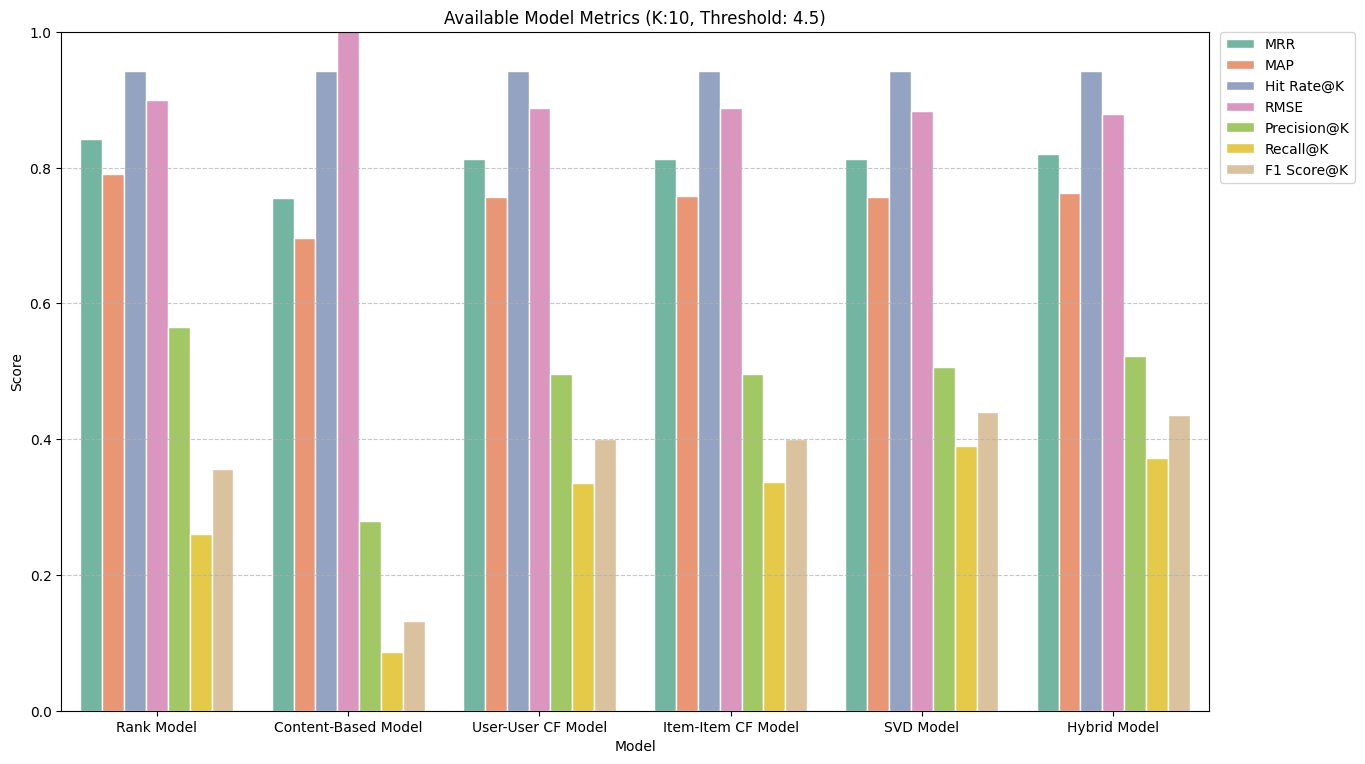

In [175]:
# Compare whichever model metrics are currently available in the notebook kernel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

if "prepare_and_display_metrics" not in globals():
    import sys
    if "../" not in sys.path:
        sys.path.append("../")
    from src.utils import prepare_and_display_metrics

if "palette_color" not in globals():
    palette_color = "tab10"

if "k" not in globals():
    k = 10

if "threshold" not in globals():
    threshold = 4.5

metrics = {}
algo_names = []

if "model_rank_metric" in globals():
    metrics["Rank Model"] = model_rank_metric[1]
    algo_names.append(getattr(model_rank, "algo_name", "BAvg"))

if "content_based_metric" in globals():
    metrics["Content-Based Model"] = content_based_metric
    algo_names.append("Content-Based")

if "model_uu_opt_metric" in globals():
    metrics["User-User CF Model"] = model_uu_opt_metric[1]
    algo_names.append(getattr(model_uu, "algo_name", "User-User CF"))

if "model_ii_opt_metric" in globals():
    metrics["Item-Item CF Model"] = model_ii_opt_metric[1]
    algo_names.append(getattr(model_ii, "algo_name", "Item-Item CF"))

if "model_svd_opt_metric" in globals():
    metrics["SVD Model"] = model_svd_opt_metric[1]
    algo_names.append(getattr(model_svd, "algo_name", "SVD"))

if "hybrid_metric" in globals():
    metrics["Hybrid Model"] = hybrid_metric[1]
    algo_names.append(getattr(model_hybrid, "algo_name", "Hybrid"))

if not metrics:
    raise ValueError(
        "No model metrics are available yet. Run at least the Content-Based evaluation cell, "
        "or run the model training/evaluation sections before Model Comparison."
    )

prepare_and_display_metrics(metrics, algo_names, "Available Model Metrics")

metrics_df = pd.DataFrame(metrics).T.reset_index()
metrics_long = pd.melt(
    metrics_df, id_vars="index", var_name="Metric", value_name="Score"
)
metrics_long.columns = ["Model", "Metric", "Score"]
metrics_long = metrics_long.dropna(subset=["Score"])

plt.figure(figsize=(14, 8))
sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    palette=palette_color,
    data=metrics_long,
    edgecolor="white",
)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0.0)
plt.title(f"Available Model Metrics (K:{k}, Threshold: {threshold})")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(0, 1)
plt.tight_layout(pad=2.0)
plt.show()


**Observations**:

The dominance of popular items in the recommendations is a common characteristic across these collaborative filtering techniques due to the nature of sparse data and interaction patterns, often leading to inflated ranking metrics and overfitting struggles. This comparison explores how each model balances predictive accuracy, ranking performance, and the challenges posed by sparsity, cold start, and overfitting.

- **RMSE**: The **Hybrid Model** achieves the lowest RMSE (0.879), indicating better predictive accuracy compared to the individual models. The **Rank Model** has the highest RMSE (0.899), reflecting its reliance on **Bayesian Averages** which may not capture individual preferences as effectively.
- **Precision@K**: The **Rank Model** achieves the highest precision (0.565), with the **Hybrid Model** following at 0.522. This indicates that the hybrid approach still improves top-10 recommendation relevance compared to other collaborative filtering methods.
- **Recall@K**: The **SVD Model** demonstrates the highest recall (0.391), indicating a stronger ability to capture relevant items across the dataset. However, the **Hybrid Model** closely follows with a recall of 0.375, showing that it balances between ranking and prediction accuracy.
- **Ranking Metrics**: The **Rank Model** leads in **MRR** (0.842) and **MAP** (0.791), suggesting that it effectively ranks the most popular items. The **Hybrid Model** achieves the second-highest **MRR** (0.819) and **MAP** (0.763), indicating a good balance between the collaborative and rank-based approaches.
- **Hit Rate@K**: All models show a high hit rate of 0.943, demonstrating their effectiveness in including at least one relevant item within the top-K recommendations, regardless of their underlying method.

### Export of Tuned Model

In [176]:
# Export the tuned SVD model only when the SVD training cells have been run
from pathlib import Path
import pickle

filename = Path("../models/final_model_svd.pkl")

if "model_svd" in globals():
    if "reader" not in globals():
        from surprise.reader import Reader
        reader = Reader(rating_scale=(0, 5))

    if "Dataset" not in globals():
        from surprise.dataset import Dataset

    full_data = Dataset.load_from_df(df[["user_id", "prod_id", "rating"]], reader)
    full_trainset = full_data.build_full_trainset()

    final_model = model_svd.model
    final_model.fit(full_trainset)

    with open(filename, "wb") as f:
        pickle.dump(final_model, f)

    print(f"Parameters: {model_svd.best_params}")
    print(f"Tuned model exported successfully to '{filename}'")
elif filename.exists():
    with open(filename, "rb") as f:
        final_model = pickle.load(f)
    print(
        f"Loaded existing tuned model from '{filename}'. "
        "Run the SVD training cells first if you want to retrain and export it."
    )
else:
    print(
        "Skipping tuned model export because model_svd is not defined. "
        "Run the SVD training/tuning section first."
    )


Parameters: {'n_factors': 11, 'n_epochs': 56, 'lr_all': 0.003, 'reg_all': 0.22, 'random_state': 42}
Tuned model exported successfully to '..\models\final_model_svd.pkl'


In [177]:
# End the timer at the end of the notebook
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Print the elapsed time in a readable format
print(f"Notebook runtime: {elapsed_time:.2f} seconds")
print(f"Notebook runtime: {(elapsed_time/60):.2f} minutes")

Notebook runtime: 1459.72 seconds
Notebook runtime: 24.33 minutes


## Conclusion and Recommendations

### Conclusion

This project analyzed and compared multiple recommendation models using the Amazon product reviews dataset focused on electronic products. The evaluation revealed that data sparsity, overfitting, and the dominance of popular items significantly impacted the models' performance.

**Key Findings**

- The dataset is highly sparse, containing only **78,798 recorded interactions** out of a possible **10 million** user-product combinations. Additionally, there is a strong **skew towards high ratings**, with **over 82%** of ratings being **4 or higher**. This sparsity and positive rating bias complicate model generalization, reducing the ability to discern finer differences in user preferences and often leading to less diverse recommendations.
- User-product interactions exhibit a **right-skewed distribution** with limited engagement overall, most users have **10 to 50 interactions** and most products are interacted with by **1 to 10 users**, while a **small subset of users and products dominate interactions**, creating notable outliers that can introduce bias in model training.
- **Data sparsity** heavily impacts the models, causing them to favor frequently and highly rated items, which artificially inflates metrics like **Precision@K**, **MRR**, **MAP**, and **Hit Rate@K**. This bias results in overfitting to popular items, failing to capture diverse user preferences and ultimately **lowering Recall@K** by neglecting niche or less common yet relevant items. Despite model tuning, **overfitting** remains an ongoing challenge due to the sparse interactions.
- The **cold start problem** not only affects new users but also new or rarely rated products, such as newly launched electronics, which struggle to gain visibility in recommendations due to the models’ reliance on past interactions.

**Hybrid Model Performance**

- The **Hybrid Model** emerges as the **most balanced approach**, achieving the **lowest RMSE** by combining the strengths of **Rank-Based** and **Model-Based Collaborative Filtering** methods. This integration allows the model to capture high **Precision@K** and **Recall@K**, with an **F1 Score@K** that rivals the best from individual models. 
- Its low RMSE demonstrates a strong balance between fitting the training data and generalizing to new interactions, showcasing its predictive accuracy. This balance makes it a valuable tool for enhancing personalized recommendations in an e-commerce context.
- Beyond securing the **second-highest Recall@K** and **Precision@K**, the hybrid model also maintains strong **ranking metrics** like **MRR** and **MAP**, reflecting its proficiency in identifying and ranking relevant items effectively.
- The hybrid model incorporates the **Rank-Based** approach to effectively address the **cold start problem**, providing meaningful recommendations for new users with limited interaction data
- Despite these strengths, it still **remains influenced by data sparsity** and **biased toward popular items**. Addressing these challenges, such as by incorporating additional data features or exploring more advanced techniques, is crucial to further enhance its generalization and capture a broader range of user preferences.

### Recommendations

Enhancing the recommendation system is anticipated to significantly boost customer engagement, conversion rates, and retention, thereby driving overall business growth. Monitoring key performance metrics is crucial for assessing the impact of these improvements and guiding further optimization efforts.

**Diversifying Recommendation Strategies**

- **Content and Metadata Integration**: Utilize content-based filtering by leveraging machine learning algorithms that analyze product features and metadata (e.g., product descriptions, brands, and categories) to identify similarities between products. This approach enables the recommendation system to suggest items that closely align with a user's interests, even if those items have limited historical interaction data, thereby addressing not only the **cold start problem** but also mitigating issues related to **data sparsity**.
- **Address Data Sparsity**: Implement data augmentation techniques like synthetic interactions and active learning to selectively gather more data for items with sparse interactions. Incorporate implicit feedback signals (e.g., clicks, views, add-to-cart events) to enrich the dataset, thus reducing reliance on popular items and fostering more diverse, accurate recommendations.
- **Continuous Model Evaluation**: Regularly fine-tune model parameters to adapt to changing data patterns, maintaining robustness and improving recommendation quality.
- **Metric Reevaluation**: Introduce metrics such as coverage and novelty to better assess the models' effectiveness in generating diverse recommendations, particularly within sparse datasets. Utilize weighted sampling during training to emphasize underrepresented items and users, ensuring a more balanced model evaluation.

**Strategic Business Actions**

- **A/B Testing for Optimization**: Conduct A/B tests to compare the effectiveness of different recommendation strategies (e.g., personalized vs. trending lists). Use key metrics—**Click-Through Rate (CTR)**, **Conversion Rates**, **Average Order Value (AOV)**, and **Customer Lifetime Value (CLV)**—to identify the most successful approaches and optimize the system continuously.
- **Personalize Marketing Campaigns**: Leverage the hybrid recommendation system to tailor marketing efforts, such as curated email campaigns based on browsing and purchase history. Monitor **CTR** and **Conversion Rates** to gauge engagement and refine future strategies.
- **Target Less Engaged Segments**: Identify and re-engage customer segments with low interaction rates through tailored recommendations, aiming to reduce **Churn Rate** and enhance **CLV**.
- **Diversify Product Promotion**: Adjust the recommendation algorithm to feature lesser-known products alongside top sellers by incorporating a **novelty factor**. Monitor **sales growth** and **AOV** to evaluate the impact of diversifying the product mix in user experiences, assessing both immediate and long-term impacts on customer engagement and satisfaction.


---